In [ ]:
# Khởi tạo thư viện
import pandas as pd
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Import hai file CSV
df_engagement = pd.read_csv('/content/drive/MyDrive/BI10 Dataset/consumer_financial_health_engagement_2025.csv')
df_transactions = pd.read_csv('/content/drive/MyDrive/BI10 Dataset/consumer_transactions_2025.csv')


**Task 3.1. Kiểm tra phân phối của engagement_score**


---
- Kiểm tra hình thái phân phối của engagement_score trên toàn bộ sample
- Thống kê mô tả và tính tỷ trọng % khách hàng theo từng phân khúc tương tác mặc định (engagement_segment)

Minimum ouput:
- Biểu đồ phân phối phù hợp (Histogram, KDE kết hợp Boxplot)
- Bảng tỷ trọng khách hàng theo từng nhóm Engagement


In [ ]:

# Thống kê mô tả engagement_score
print('engagement_score descriptive statistics:')
print(df_engagement['engagement_score'].describe())

engagement_score descriptive statistics:
count    10992.000000
mean        77.819314
std          6.326936
min          9.700000
25%         74.800000
50%         78.100000
75%         81.400000
max         99.600000
Name: engagement_score, dtype: float64


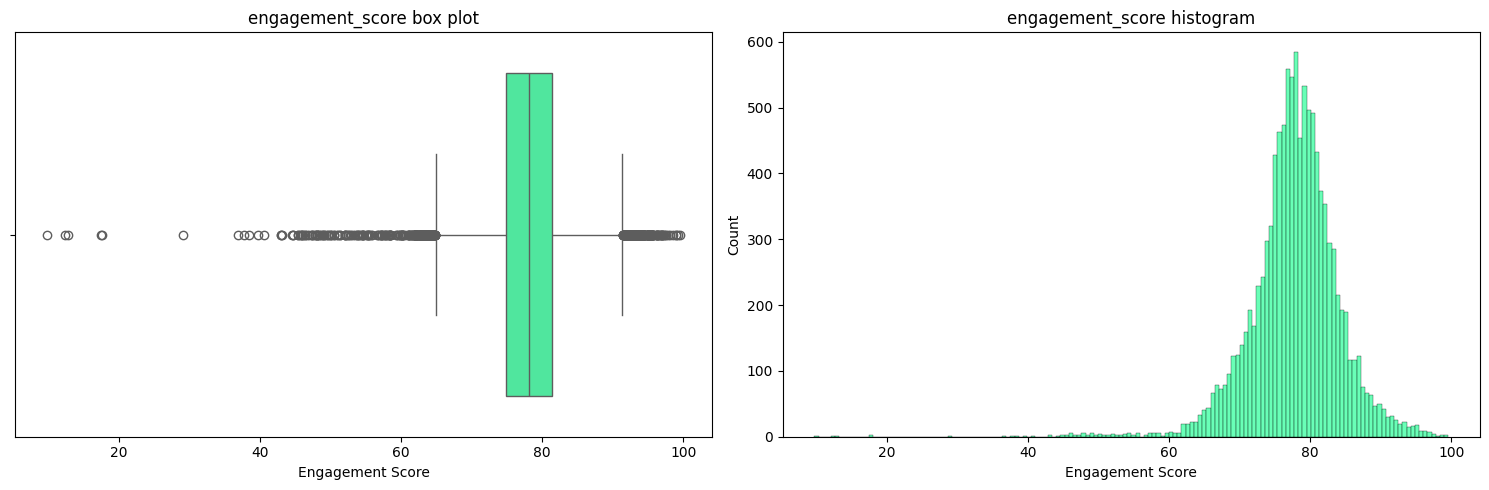

In [ ]:
# Vẽ biểu đồ kết hợp Boxplot và Histogram với KDE để kiểm tra phân phối
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Boxplot của engagement_score
sns.boxplot(ax=axes[0], x='engagement_score', data=df_engagement, color='#37ff9f')
axes[0].set_title('engagement_score box plot')
axes[0].set_xlabel('Engagement Score')

# 2. Histogram kèm KDE plot của engagement_score
sns.histplot(ax=axes[1], x='engagement_score', data=df_engagement, color='#37ff9f')
axes[1].set_title('engagement_score histogram')
axes[1].set_xlabel('Engagement Score')

plt.tight_layout()
plt.show()

In [ ]:
# Tính toán các chỉ số thống kê (Min, Max, Mean) và số lượng khách hàng cho từng nhóm
segment_stats = df_engagement.groupby('engagement_segment').agg(
    So_luong=('consumer_id', 'count'),
    Score_Min=('engagement_score', 'min'),
    Score_Max=('engagement_score', 'max'),
    Score_Mean=('engagement_score', 'mean')
).reset_index()

# Tính tỷ trọng %
total_customers = segment_stats['So_luong'].sum()
segment_stats['Proportion'] = (segment_stats['So_luong'] / total_customers) * 100

# Sắp xếp theo thứ tự phân khúc tương tác để dễ đối chiếu
segment_order = ['Tương tác thấp', 'Tương tác trung bình', 'Tương tác cao', 'Tương tác rất cao']
segment_stats['engagement_segment'] = pd.Categorical(segment_stats['engagement_segment'], categories=segment_order, ordered=True)
segment_stats = segment_stats.sort_values('engagement_segment').reset_index(drop=True)

# Định dạng hiển thị
segment_stats['Proportion'] = segment_stats['Proportion'].map('{:.2f}%'.format)
segment_stats['Score_Mean'] = segment_stats['Score_Mean'].round(2)

segment_stats[['engagement_segment', 'Proportion', 'Score_Min', 'Score_Max', 'Score_Mean']]

,engagement_segment,Proportion,Score_Min,Score_Max,Score_Mean
0,Tương tác thấp,0.09%,9.7,39.7,25.15
1,Tương tác trung bình,0.91%,40.5,59.9,52.06
2,Tương tác cao,64.21%,60.1,79.9,75.03
3,Tương tác rất cao,34.79%,80.0,99.6,83.78


**Findings:**
- Phân phối của engagement_score: left-skewed mạnh, khoảng 99% khách hàng thuộc nhóm có tương tác từ cao đến rất cao
- (Brainrot) Cơ chế chia segment theo Score: 0-40, 40-60, 60-80, 80-100
- (Trong PowerBI) Nhóm tương tác thấp và tương tác trung bình là nhóm già nhất với độ tuổi trung bình lần lượt 71,90 và 55,89 => Đây là nhóm người già cả, ít dùng mấy cái tín dụng điện tử này. Tuy nhiên thì nhóm tương tác cao (đông nhất) thì độ tuổi trung bình cũng khoảng 51,45, không chênh lệch quá đáng kể với nhóm tương tác trung bình

**Task 3.2. Mức độ tiếp nhận kênh thanh toán**

---
- Thống kê tỷ lệ tiếp nhận và sử dụng các kênh thanh toán (transaction_channel): POS, QR, E-commerce, Mobile App, Recurring
- Tính toán tỷ trọng chi tiêu trực tuyến trung bình (average online spend share) trên từng nhóm khách hàng
Note: Các kênh thanh toán online xác định bằng: E-commerce, Mobile App, Recurring hoặc xác định bằng online_transaction_flag = 1

Minimum output:
- Biểu đồ cơ cấu kênh (Stacked Bar Chart hoặc Treemap)
- Bảng chỉ số tỷ lệ nhận diện kênh và tỷ trọng chi tiêu online.


**Findings: (Làm trong PowerBI)**
- Các hình thức thanh toán Offline (POS, QR Payment) áp đảo về cả số lượt giao dịch lẫn tổng giá trị giao dịch
- Average Online Spend Share (đề hỏi) khoảng 25,72%
- Lượng giao dịch và tổng giá trị giao dịch giữa các channel đều nhau (không có cái nào lượng giao dịch cao nhưng giá trị thấp). Xu hướng này diễn ra đều, không biến động theo thơi gian.
- E-Commerce có giá trị trung bình mỗi giao dịch (Value per Transaction) cao nhất, tuy nhiên metrics này giữa các channel nhìn chung khá đồng đều => check thêm xu hướng
- Breakdown Value per Transaction theo Channel:

**Với các kênh Online (E-Commerce, Mobile App, Recurring)**: Ít category (3-5). Các category dẫn đầu có VpT không quá cao, giữa các category đầu và cuối không giảm quá sâu.

**Với các kênh Offline (POS, QR Payment)**: Có tới 11 category, đa dạng. Các category dẫn đầu là Siêu thị, Du lịch có VpT cao nổi bật so với các category khác (từ 2,8tr đến gần 3tr). Tuy nhiên, các category còn lại khá thấp nên kéo VpT của cả kênh xuống thấp.

=> Root cause: VpT giữa các kênh đồng đều nhưng có bản chất khác nhau. Nhóm kênh Online là do các kênh không quá chênh lệch, nhóm Offline là do đa dạng Catergory, các category đầu cao nhưng bị kéo xuống.  



**Task 3.3. Độ đa dạng và mức độ tương tác**

---
- Tính số lượng danh mục ngành hàng mà một khách hàng thường xuyên sử dụng
- Phân tích mối liên hệ: Liệu khách hàng chi tiêu ở càng nhiều danh mục khác nhau thì điểm tương tác có càng cao không?
Hoặc phát triển thêm các hướng phân tích khác

Minimum Output:
- Biểu đồ Scatter Plot hoặc Boxplot thể hiện tương quan giữa số danh mục và engagement_score
- Insight định lượng về khoảng dao động danh mục


In [ ]:
# 1. Lấy thông tin trung bình của 'engagement_score' và 'category_diversity' theo từng khách hàng từ df_engagement
df_consumer_metrics = df_engagement[['engagement_score','category_diversity', 'average_transaction_value_vnd']]

# 2. Tính hệ số tương quan Pearson
correlation1 = df_consumer_metrics['category_diversity'].corr(df_consumer_metrics['engagement_score'])
print(f"Pearson correlation between category_diversity and engagement_score: {correlation1:.4f}")
print()
correlation2 = df_consumer_metrics['category_diversity'].corr(df_consumer_metrics['average_transaction_value_vnd'])
print(f"Pearson correlation between category_diversity and average_trasaction_value_vnd: {correlation2:.4f}")

Pearson correlation between category_diversity and engagement_score: 0.5897

Pearson correlation between category_diversity and average_trasaction_value_vnd: -0.7205


**Findings:**
- Trong 1 tháng, đại đa số mọi người đều thực hiện giao dịch trên cả 14 category (Chiếm 80,8%)
- Giữa engagement_score và category_diversity có mối tương quan khá dương: Correlation giữa 2 biến này là khoảng xấp xỉ gân 0.6. Xét về phân bổ: với category_diversity thấp (từ 2 đến 7), engagement_score nhìn chung tương đối thấp, nhưng dao động mạnh và khá rộng (từ 9,7 đến 61,6). Ngược lại, với category_diversity cao (từ 8 đến 14), engagement_score luôn cao và ít phân tán hơn.
- Giữa engagement_score và average_transaction_value_vnd có mối tương quan tiêu cực mạnh: correlation = -0.7205. Phân bổ cho thấy 2 nhóm có category_diversity cao (>=8) và thấp (<=7) tập trung ở 2 vùng khác nhau rõ rêt. Nhóm cao co cụm lại ở khu vực có avg transaction value dưới 5tr và phân tán khá hẹp. Trong khi đó nhóm có category_diversity thấp thì lại có avg transaction value khá cao, phân tán rộng.
- Ngoài ra, xét mối quan hệ giữa category_diversity và active_transaction_days cho thấy pattern đặc biệt: category_diversity thấp (từ 2 đến 7) chỉ có tối đa 2 ngày thực hiện giao dịch trong 1 tháng, trong khi nhóm có thực hiện giao dịch trên nhiều category hơn thì có số ngày thực hiện giao dịch trong tháng nhiều hơn đáng kể (min 15 ngày) và trải rộng hơn. Như vậy có thể nói là người thực hiện giao dịch trên ít category thì cũng sẽ ít giao dịch (về số ngày) trong 1 tháng hơn.
- Như vậy, có thể phân khúc khách hàng của doanh nghiệp này thành 2 nhóm chính dựa trên diversity và các yếu tố liên quan đến engagement:

Nhóm 1 có giao dịch đa dạng category, có active_transaction_days cao và giá trị giao dịch trung bình thấp. Nhóm này chắc là nhóm dùng thẻ nhiều cho chi tiêu hàng ngày, giao dịch nhỏ lẻ

Nhóm 2 có giao dịch ít category, có active_transaction_days thấp và giá trị giao dịch trung bình cao. Nhóm này chắc là chỉ dùng thẻ cho vài những giao dịch quan trọng, có giá trị lớn, không thường xuyên
- Xét thêm mối quan hệ giữa diversity và discretionary_spend_ratio thì xác nhận điều này: nhóm diversity thấp chỉ chi tiêu cho hàng hóa không thiết yếu, còn nhóm diversity cao thì phân bố rộng, vừa chi tiêu cho hàng thiết yếu, vừa không thiết yếu.
- How does diversity link to engagement? => category_diversity là chỉ báo đáng tin cậy của nhóm khách hàng engaged cao, hữu ích để nhận diện/phân khúc. Nhóm có diversity cao thì cũng có engagement cao hơn và ngược lại.

**Task 3.4. Tần suất và độ mới giao dịch**

---
- Khảo sát khoảng giá trị và phân bố của: Frequency (tần suất giao dịch/tháng) và Recency (số ngày kể từ lần giao dịch gần nhất)
- Phân tích mức độ liên kết giữa Recency, Frequency với điểm tương tác (engagement_score)


In [ ]:
# Khảo sát phân phối Freqency (Thể hiện qua 2 biến transaction_count và active_transaction_days)

In [ ]:
print('active_transaction_days descriptive statistics:')
print(df_engagement['active_transaction_days'].describe())
print()
print('transaction_count descriptive statistics:')
print(df_engagement['transaction_count'].describe())

active_transaction_days descriptive statistics:
count    10992.000000
mean        28.631277
std          3.688668
min          1.000000
25%         28.000000
50%         30.000000
75%         31.000000
max         31.000000
Name: active_transaction_days, dtype: float64

transaction_count descriptive statistics:
count    10992.000000
mean       168.522016
std        106.389998
min          2.000000
25%         83.000000
50%        150.000000
75%        223.000000
max        713.000000
Name: transaction_count, dtype: float64


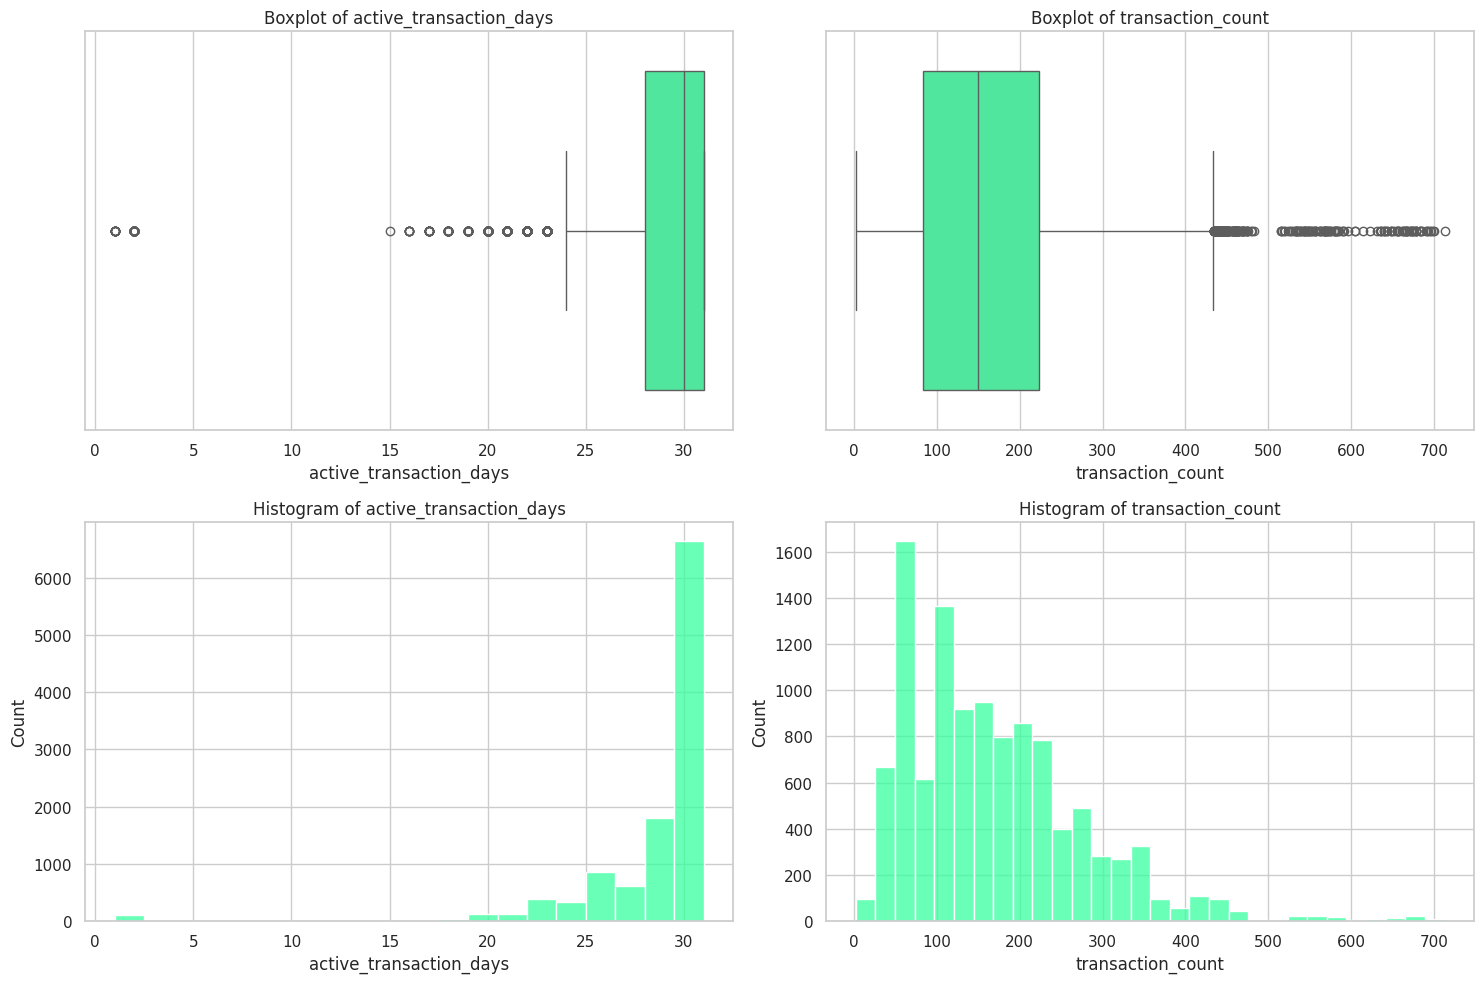

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# --- 1. active_transaction_days ---
# Boxplot
sns.boxplot(ax=axes[0, 0], x='active_transaction_days', data=df_engagement, color='#37ff9f')
axes[0, 0].set_title('Boxplot of active_transaction_days')
axes[0, 0].set_xlabel('active_transaction_days')

# Histogram
sns.histplot(ax=axes[1, 0], x='active_transaction_days', data=df_engagement, kde=False, color='#37ff9f', bins=20)
axes[1, 0].set_title('Histogram of active_transaction_days')
axes[1, 0].set_xlabel('active_transaction_days')
axes[1, 0].set_ylabel('Count')

# --- 2. transaction_count ---
# Boxplot
sns.boxplot(ax=axes[0, 1], x='transaction_count', data=df_engagement, color='#37ff9f')
axes[0, 1].set_title('Boxplot of transaction_count')
axes[0, 1].set_xlabel('transaction_count')

# Histogram
sns.histplot(ax=axes[1, 1], x='transaction_count', data=df_engagement, kde=False, color='#37ff9f', bins=30)
axes[1, 1].set_title('Histogram of transaction_count')
axes[1, 1].set_xlabel('transaction_count')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
# Khảo sát phân phối Recency (thể hiện qua biến transaction_recency_days)

In [ ]:
#Thống kê mô tả
print('transaction_recency_days descriptive statistics:')
print(df_engagement['transaction_recency_days'].describe())

transaction_recency_days descriptive statistics:
count    10992.000000
mean         0.166121
std          1.545556
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         30.000000
Name: transaction_recency_days, dtype: float64


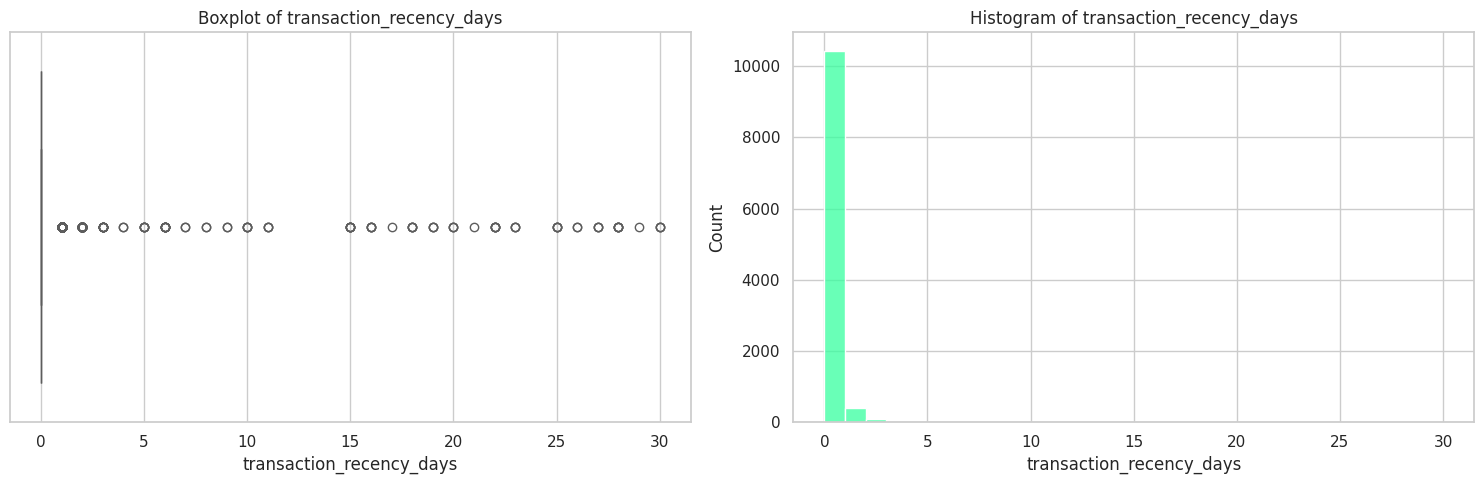

In [ ]:
#Kiểm tra phân phối
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Boxplot của transaction_recency_days
sns.boxplot(ax=axes[0], x='transaction_recency_days', data=df_engagement, color='#37ff9f')
axes[0].set_title('Boxplot of transaction_recency_days')
axes[0].set_xlabel('transaction_recency_days')

# 2. Histogram của transaction_recency_days
sns.histplot(ax=axes[1], x='transaction_recency_days', data=df_engagement, kde=False, color='#37ff9f', bins=30)
axes[1].set_title('Histogram of transaction_recency_days')
axes[1].set_xlabel('transaction_recency_days')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
# Kiểm tra mối quan hệ giữa Frequency, Recency và Engagement

In [ ]:
# Tính toán hệ số tương quan giữa engagement_score với các biến Recency và Frequency
corr_recency = df_engagement['engagement_score'].corr(df_engagement['transaction_recency_days'])
corr_active_days = df_engagement['engagement_score'].corr(df_engagement['active_transaction_days'])
corr_count = df_engagement['engagement_score'].corr(df_engagement['transaction_count'])

print(f"Pearson correlation between engagement_score and transaction_recency_days: {corr_recency:.4f}")
print(f"Pearson correlation between engagement_score and active_transaction_days:  {corr_active_days:.4f}")
print(f"Pearson correlation between engagement_score and transaction_count:       {corr_count:.4f}")

Pearson correlation between engagement_score and transaction_recency_days: -0.4239
Pearson correlation between engagement_score and active_transaction_days:  0.5894
Pearson correlation between engagement_score and transaction_count:       0.4041


In [ ]:
# Áp dụng phép biến đổi logarit cho transaction_count
df_engagement['log_transaction_count'] = np.log1p(df_engagement['transaction_count'])

# Tính toán lại tương quan với engagement_score
corr_log_count = df_engagement['engagement_score'].corr(df_engagement['log_transaction_count'])

print(f"Pearson correlation between engagement_score and log_transaction_count: {corr_log_count:.4f}")

Pearson correlation between engagement_score and log_transaction_count: 0.5555


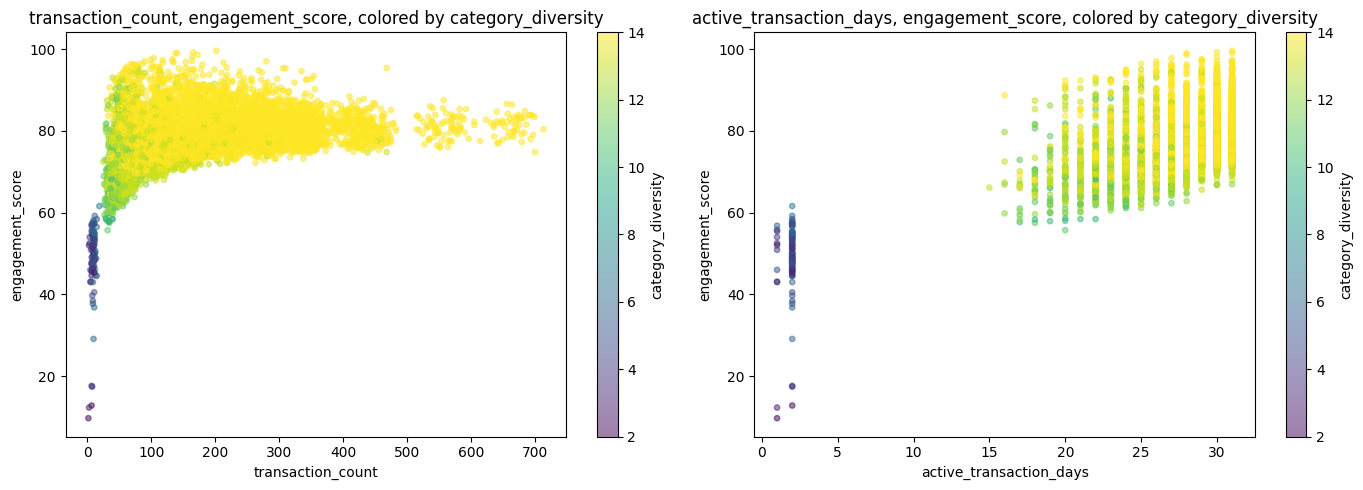

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter 1: transaction_count vs engagement_score, tô màu theo category_diversity
sc1 = axes[0].scatter(
    df_engagement['transaction_count'],
    df_engagement['engagement_score'],
    c=df_engagement['category_diversity'],
    cmap='viridis', alpha=0.5, s=15
)
axes[0].set_xlabel('transaction_count')
axes[0].set_ylabel('engagement_score')
axes[0].set_title('transaction_count, engagement_score, colored by category_diversity')
plt.colorbar(sc1, ax=axes[0], label='category_diversity')

# Scatter 2: active_transaction_days vs engagement_score, tô màu theo category_diversity
sc2 = axes[1].scatter(
    df_engagement['active_transaction_days'],
    df_engagement['engagement_score'],
    c=df_engagement['category_diversity'],
    cmap='viridis', alpha=0.5, s=15
)
axes[1].set_xlabel('active_transaction_days')
axes[1].set_ylabel('engagement_score')
axes[1].set_title('active_transaction_days, engagement_score, colored by category_diversity')
plt.colorbar(sc2, ax=axes[1], label='category_diversity')

plt.tight_layout()
plt.show()

In [ ]:
from scipy import stats
import numpy as np

# Partial correlation: corr(diversity, engagement | control for transaction_count)
def partial_corr(x, y, control):
    # Hồi quy x theo control, lấy residual
    slope_x, intercept_x, _, _, _ = stats.linregress(control, x)
    resid_x = x - (slope_x * control + intercept_x)

    # Hồi quy y theo control, lấy residual
    slope_y, intercept_y, _, _, _ = stats.linregress(control, y)
    resid_y = y - (slope_y * control + intercept_y)

    # Correlation giữa 2 phần residual
    return np.corrcoef(resid_x, resid_y)[0, 1]

pc = partial_corr(
    df_engagement['category_diversity'].values,
    df_engagement['engagement_score'].values,
    df_engagement['transaction_count'].values
)
print(f"Partial correlation (category_diversity, engagement_score | control transaction_count): {pc:.4f}")

Partial correlation (category_diversity, engagement_score | control transaction_count): 0.5243


**Findings:**
1. Về phân phối của Frequency (thể hiện thông qua active_transaction_days và transaction_count) và Recency:

**Frequency**
- Với active_transaction_days: Phân phối lệch trái mạnh, dồn cục ở vùng 28-31 ngày (gần như active cả tháng); box rất hẹp (IQR nhỏ), đa số khách hàng rất đồng nhất ở mức cao. Có khoảng trống rõ rệt giữa nhóm ≤2 ngày và nhóm ≥15 ngày, không có điểm nào ở giữa (8-14 ngày gần như trống). Biến này bị chặn trần tự nhiên bởi số ngày trong tháng (max 31) → khiến khách hàng dùng thẻ thường xuyên nhanh chóng dồn cục ở vùng cao, làm giảm khả năng phân biệt
- Với transaction_count: Phân phối lệch phải vừa phải, đơn đỉnh mượt, đỉnh ở 50-100 giao dịch, giảm dần đều. Không bị hiệu ứng trần như active_days (1 ngày có thể có nhiều giao dịch) → phân tán tự nhiên hơn, phân biệt tốt hơn giữa các mức cường độ sử dụng.

=> transaction_count phản ánh frequency tốt hơn

**Recency**
- Phân phối cực kỳ lệch trái, gần như một cột đơn: đại đa số áp đảo có recency = 0, đuôi rất mỏng. Cả 3 mốc phân vị Q1, Median, Q3 đều bằng 0.
2. Mối quan hệ giữa Frequency, Recency và Engagement

Correlation với Engagement:
- transaction_recency_days:	                                 -0.4239
- active_transaction_days: 	                                 0.5894 (mạnh nhất)
- transaction_count:                                         0.4041
- transaction_count (log-transformed):                       0.5555
- category_diversity (tham chiếu, từ phân tích trước):       ~0.60
- Partial corr(diversity, engagement | control count):       0.5243

Frequency and Engagement:

- **Recency and Engagement:** Xu hướng nghịch biến rõ: Khi recency days tăng lên, engagement_score giảm xuống, độ dốc giảm rất cao trong khoảng từ 0-5 ngày, sau đó thoải và gần như trải phẳng trong khoảng từ 5-30 ngày. Đặc biệt: recency không phân biệt được giữa nhóm Tương tác trung bình và Tương tác thấp (trải đều). Ngược lại, Tương tác cao và Tương tác rất cao chỉ xuất hiện ở vùng recency 0-3, tách biệt hẳn khỏi 2 nhóm còn lại.


- **Frequency theo transaction_count và Engagement:** Phân phối dạng đường cong logarit, tăng rất nhanh khi count từ 0-100, sau đó gần như bão hòa ở mức 75-90 dù count tiếp tục tăng đến 700+. Đặc biệt, nhóm Cao và Rất cao tách thành 2 dải rõ rệt, gần như không giao nhau, nghĩa là cùng một mức tần suất vẫn có 2 mức engagement khác nhau, chứng tỏ Frequency theo count không giải thích hết sự phân biệt giữa 2 nhóm này.

- **Frequency theo active_transaction_days và Engagement:** Có correlation lớn nhất trong tất cả (~0.6). Những Customer có active days càng cao cũng có xu hướng có engagement_score cao hơn. Tương tự như trên, ở vùng có active_transaction_days cao (từ 15 trở lên) thì cũng xuất hiện hiện tượng 2 nhóm Cao và Rất cao tách thành 2 dải rõ rệt như trên. Điều này cho thấy Frequency theo active_transaction_days cũng không phải là yếu tố giải thích hết được sự phân biệt giữa 2 nhóm này.

Như vậy, Frequency là cần nhưng chưa đủ để phân biệt 2 nhóm engagement Cao và Rất cao này => Còn có thể có yếu tố khác => Tìm thêm => Dựa trên task trước thì đó có thể là diversity
**Phát hiện thêm (Claude):** category_diversity là biến giải thích cho sự phân biệt này. Được xác nhận qua 2 bằng chứng:
1. Trực quan: khi tô màu scatter theo category_diversity, gradient màu thẳng hàng hoàn hảo theo chiều dọc (dải trên = màu đậm, diversity cao, dải dưới = màu nhạt, diversity thấp).
2. Định lượng: Partial correlation = 0.5243 rất cao (chỉ giảm nhẹ so với correlation thô 0.6 ban đầu). Điều này có nghĩa: sau khi đã loại bỏ hoàn toàn ảnh hưởng của transaction_count, category_diversity vẫn giải thích được một phần lớn, độc lập của engagement_score.

Như vậy, Frequency/Recency và Diversity là 2 yếu tố độc lập cùng ảnh hưởng đến engagement_score.

**How they link to engagement:** Frequency cao, Recency thấp thì Engagement cao và ngược lại. Bên cạnh đó, Engagement_score nhiều khả năng được cấu thành từ ít nhất 2 trục hành vi độc lập, (1) mức độ hoạt động thường xuyên/gần đây (Frequency + Recency) và (2) mức độ đa dạng hành vi chi tiêu (Diversity).


**Task 3.5. Định vị nhóm khách hàng High Health - Low Engage**

---
- Nhận diện nhóm khách hàng: Tài chính rất lành mạnh nhưng mức độ tương tác lại rất thấp (nguy cơ rời bỏ dịch vụ - Churn risk dù đây là tệp khách hàng tiềm năng)
- Tự xác định và công bố rõ threshold để định nghĩa thế nào là "Cao" và "Thấp" do đề bài không cung cấp sẵn
- Phải lý giải được lý do chọn ngưỡng này thay vì các ngưỡng khắt khe hơn hoặc nới lỏng hơn
- Tính toán chính xác quy mô (số lượng KH và tỷ lệ % trên tổng tệp) cùng chân dung chi tiết của nhóm này


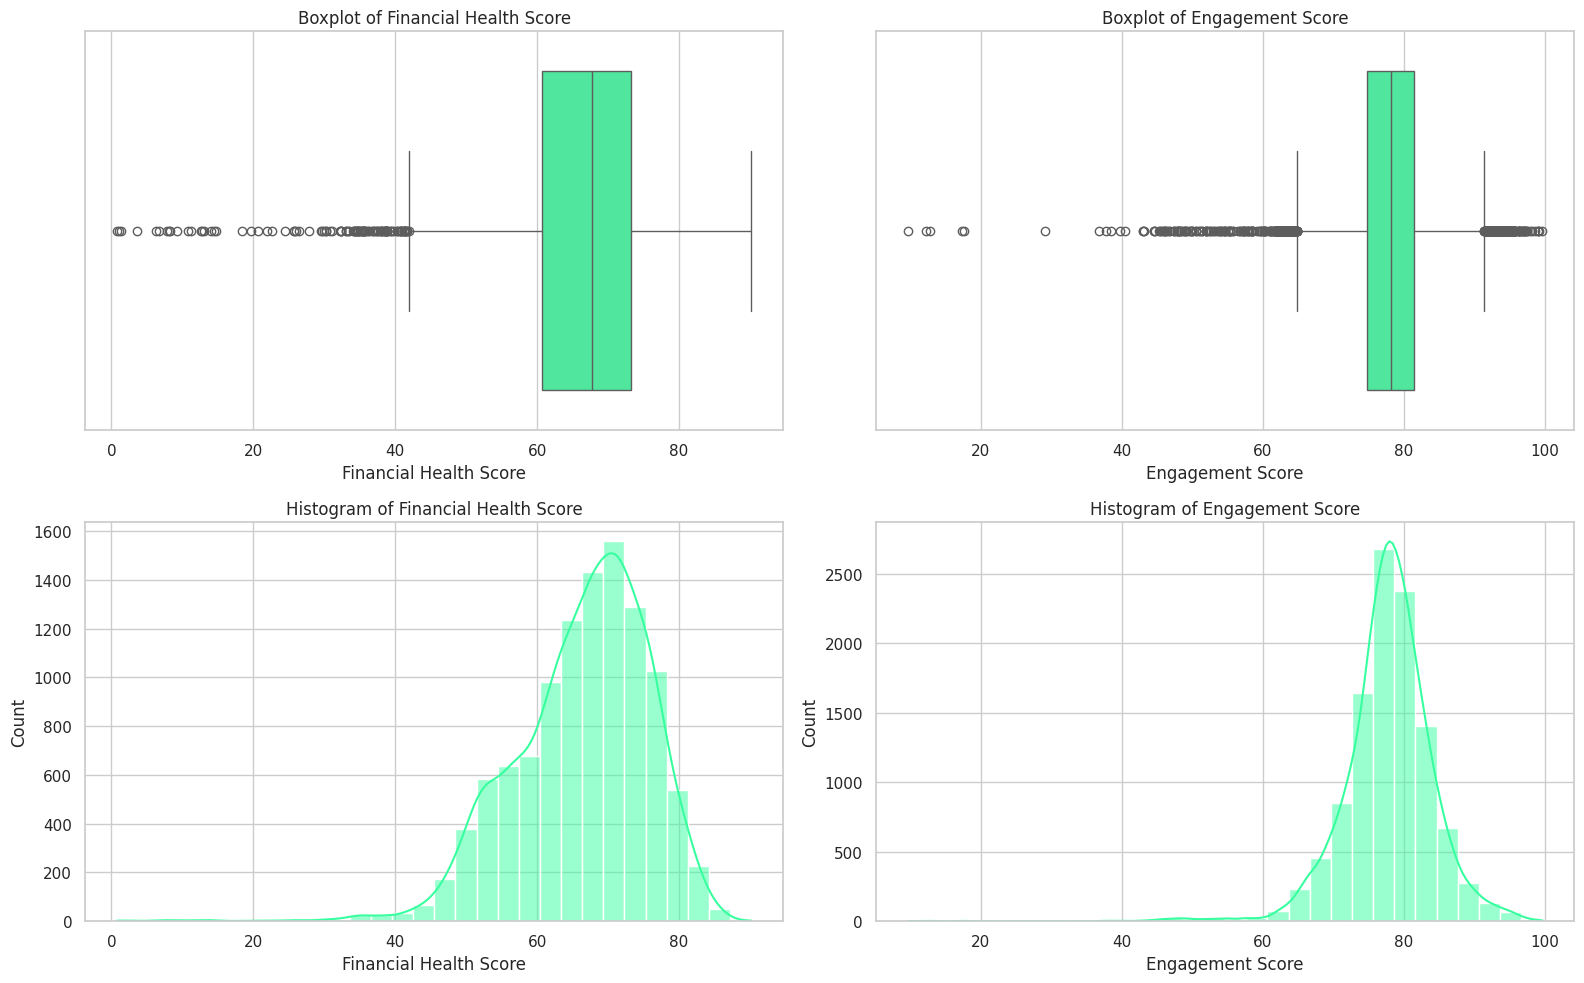


Financial Health Score Descriptive Statistics:
count    10992.000000
mean        66.365975
std          9.476034
min          0.800000
25%         60.700000
50%         67.700000
75%         73.200000
max         90.200000
Name: financial_health_score, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Khởi tạo khung vẽ gồm 2 hàng và 2 cột để vẽ Boxplot và Histogram cho cả 2 biến
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- 1. Phân phối của financial_health_score ---
sns.boxplot(ax=axes[0, 0], x='financial_health_score', data=df_engagement, color='#37ff9f')
axes[0, 0].set_title('Boxplot of Financial Health Score')
axes[0, 0].set_xlabel('Financial Health Score')

sns.histplot(ax=axes[1, 0], x='financial_health_score', data=df_engagement, kde=True, color='#37ff9f', bins=30)
axes[1, 0].set_title('Histogram of Financial Health Score')
axes[1, 0].set_xlabel('Financial Health Score')
axes[1, 0].set_ylabel('Count')

# --- 2. Phân phối của engagement_score ---
sns.boxplot(ax=axes[0, 1], x='engagement_score', data=df_engagement, color='#37ff9f')
axes[0, 1].set_title('Boxplot of Engagement Score')
axes[0, 1].set_xlabel('Engagement Score')

sns.histplot(ax=axes[1, 1], x='engagement_score', data=df_engagement, kde=True, color='#37ff9f', bins=30)
axes[1, 1].set_title('Histogram of Engagement Score')
axes[1, 1].set_xlabel('Engagement Score')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# In thống kê mô tả cơ bản của financial_health_score để hỗ trợ chọn threshold
print()
print("Financial Health Score Descriptive Statistics:")
print(df_engagement['financial_health_score'].describe())

In [ ]:
# Tính toán các chỉ số thống kê và tỷ trọng cho từng nhóm trong financial_health_segment
health_segment_stats = df_engagement.groupby('financial_health_segment').agg(
    So_luong=('consumer_id', 'count'),
    Score_Min=('financial_health_score', 'min'),
    Score_Max=('financial_health_score', 'max'),
    Score_Mean=('financial_health_score', 'mean')
).reset_index()

# Tính tỷ trọng %
total_consumers = health_segment_stats['So_luong'].sum()
health_segment_stats['Proportion'] = (health_segment_stats['So_luong'] / total_consumers) * 100

# Sắp xếp theo thứ tự điểm trung bình tăng dần
health_segment_stats = health_segment_stats.sort_values('Score_Mean').reset_index(drop=True)

# Định dạng hiển thị
health_segment_stats['Proportion'] = health_segment_stats['Proportion'].map('{:.2f}%'.format)
health_segment_stats['Score_Mean'] = health_segment_stats['Score_Mean'].round(2)

# Sắp xếp và lựa chọn lại các cột theo yêu cầu: Bỏ So_luong, Proportion lên trước Score_Min
cols_order = ['financial_health_segment', 'Proportion', 'Score_Min', 'Score_Max', 'Score_Mean']
health_segment_stats = health_segment_stats[cols_order]

# Hiển thị bảng kết quả
display(health_segment_stats)


,financial_health_segment,Proportion,Score_Min,Score_Max,Score_Mean
0,Có dấu hiệu căng thẳng tài chính,0.86%,0.8,39.9,29.09
1,Cần theo dõi,22.35%,40.3,59.9,53.88
2,Ổn định,72.46%,60.0,79.9,69.73
3,Khỏe mạnh,4.32%,80.0,90.2,82.03


**Findings:**
- Phân phối của financial_health_score gần phân phối chuẩn hơn, đối xứng tốt, không lệch mạnh như của engagement_score, có đuôi ở cả 2 phía.
- Về financial_health_segment: Nhóm Khỏe mạnh chỉ chiếm 4.32%, nhưng khác với engagement_score ( 2 nhóm cao nhất chiếm 99%), ở đây nhóm Ổn định + Khỏe mạnh cộng lại là 76.78%. Tức là phần lớn khách hàng đã ở mức health tạm ổn trở lên.
- So sánh các segment giữa financial_health và engagement: Nhóm cao nhất ở financial_health chiếm 4.32%, còn engagement chiếm 34.79%. 2 nhóm thấp nhất ở financial_health chiếm 23.21%, còn ở engagement là 1.0%. Do đó, không thể dùng cách định nghĩa High và Low giống nhau ở financial_health và engagement.
- Cách định nghĩa High và Low: dùng percentile thay vì dùng cột segment có sẵn vì: (1) với financial_health: segment Khỏe mạnh (nếu xem là High) chỉ chiếm 4.32%, quá bé so với segment Rất cao của engagement_segment (34.79%). (2) với engagement_segment: gộp 2 nhóm thấp nhất lại (nếu xem là Low) chỉ 1%, trong khi 2 nhóm cuối của financial_health_segment cộng lại khoảng hơn 23%. Do đó lấy segment cho sẵn làm định nghĩa thì sẽ bị loãng, nên lấy theo percentile.



In [ ]:
# Kiểm tra các mốc percentile của financial_health_score và engagement_score
# Định nghĩa các mốc percentile cần tính (bao gồm cả mốc 25% và 75%)
all_percentiles = sorted(list(set(list(range(10, 101, 10)) + [25, 75])))

# Tạo DataFrame chứa kết quả
df_all_percentiles = pd.DataFrame({
    'Percentile': [f'{p}%' for p in all_percentiles],
    'engagement_score': [np.percentile(df_engagement['engagement_score'], p) for p in all_percentiles],
    'financial_health_score': [np.percentile(df_engagement['financial_health_score'].dropna(), p) for p in all_percentiles]
})

display(df_all_percentiles)

,Percentile,engagement_score,financial_health_score
0,10%,70.6,53.2
1,20%,73.8,58.4
2,25%,74.8,60.7
3,30%,75.6,62.4
4,40%,76.9,65.3
5,50%,78.1,67.7
6,60%,79.3,69.9
7,70%,80.6,72.0
8,75%,81.4,73.2
9,80%,82.3,74.4


**Note:**
- Label segment có sẵn trong dataset được chia theo ngưỡng score cố định: 0-40, 40-60, 60-80, 80-100. Mốc < 60 là 2 segment thấp nhất (nếu coi là Low)
- Tuy nhiên, nhìn theo percentile, mốc này ở 2 biến hoàn toàn khác nhau. Ở financial_health, nó nằm ở dưới pct25%, còn engagement mốc 60 không hiện trên bảng nữa :)). Do đó bắt buộc xử lý bằng phân phối riêng của từng biến chứ không dùng label có sẵn được.
- Đề xuất mốc cụ thể: Chọn theo mốc tứ phân vị cơ bản (Q1 đối với Low và Q3 đối với High). Vì không có điểm gãy tự nhiên, mốc hợp lý nhất nên neo vào percentile tròn, có ý nghĩa thống kê thông dụng (quartile), đồng thời kiểm tra chéo với engagement_segment/financial_health_segment.
1. Với engagement_score: Low Engagement = engagement_score <= percentile 25 (74.8 điểm). Nhóm này gần trùng với phần dưới của segment Tương tác cao (60-80) mặc định, tức là không phải khách hàng tệ tuyệt đối, mà là nhóm thấp tương đối trong dân số vốn dĩ đã engaged.
2. Với financial_health_score: High Health = financial_health_score >= percentile 75 (73.2 điểm). Nhóm này nằm gần biên trên của Ổn định tiến vào Khỏe mạnh, hợp lý để gọi là sức khỏe tài chính tốt

In [ ]:
# Gán nhãn High Financial Health và Low Engagement cho mỗi tháng của mỗi khách hàng
# 1. Tính toán giá trị percentile 25% của engagement_score và 75% của financial_health_score
pct_25_engagement = np.percentile(df_engagement['engagement_score'], 25)
pct_75_financial_health = np.percentile(df_engagement['financial_health_score'].dropna(), 75)

# 2. Tạo 2 cột gán nhãn mới (kiểu Boolean: True/False hoặc có thể chuyển thành 1/0 nếu muốn)
df_engagement['is_low_engagement'] = df_engagement['engagement_score'] <= pct_25_engagement
df_engagement['is_high_financial_health'] = df_engagement['financial_health_score'] >= pct_75_financial_health

# 3. Hiển thị thông tin kiểm tra kết quả
print(f"Ngưỡng 25% Engagement Score: {pct_25_engagement}")
print(f"Ngưỡng 75% Financial Health Score: {pct_75_financial_health}")
print("\nSố lượng bản ghi thỏa mãn mỗi nhãn:")
print(df_engagement[['is_low_engagement', 'is_high_financial_health']].sum())

print("\nVí dụ một vài dòng dữ liệu:")
display(df_engagement[['consumer_id', 'engagement_score', 'is_low_engagement', 'financial_health_score', 'is_high_financial_health']].head(10))

Ngưỡng 25% Engagement Score: 74.8
Ngưỡng 75% Financial Health Score: 73.2

Số lượng bản ghi thỏa mãn mỗi nhãn:
is_low_engagement           2795
is_high_financial_health    2752
dtype: int64

Ví dụ một vài dòng dữ liệu:


,consumer_id,engagement_score,is_low_engagement,financial_health_score,is_high_financial_health
0,KH00100010,77.4,False,74.4,True
1,KH00100010,77.1,False,76.3,True
2,KH00100010,79.0,False,71.2,False
3,KH00100010,78.0,False,69.0,False
4,KH00100010,77.9,False,75.8,True
5,KH00100010,77.5,False,69.4,False
6,KH00100010,79.5,False,65.6,False
7,KH00100010,79.2,False,70.6,False
8,KH00100010,77.7,False,73.1,False
9,KH00100010,78.8,False,70.2,False


High Health, Low Engagement Group Size:
- Size: 1,127 records
- Proportion: 10.25% of the total (10,992 records)



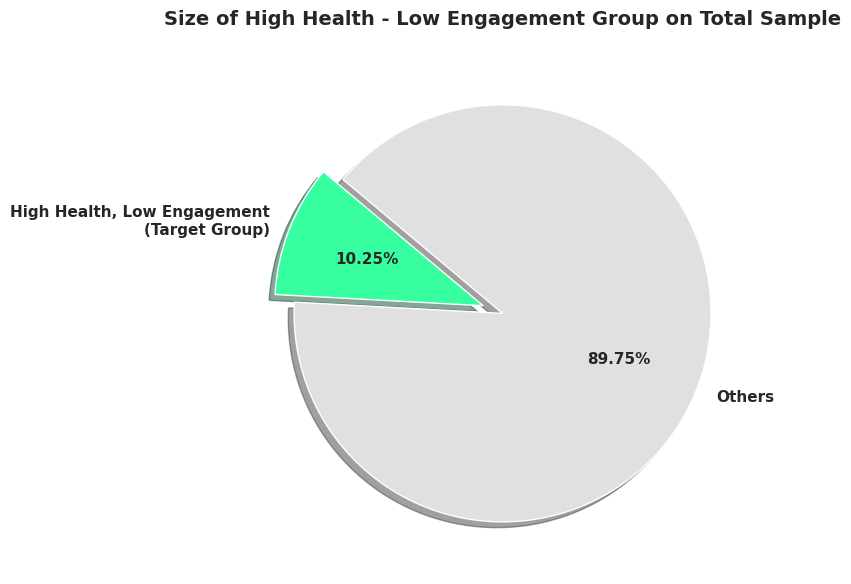

In [ ]:
# Determine size and proportion of the High Health Low Engagement group
# 1. Define High Health - Low Engagement group
df_engagement['is_high_health_low_engage'] = df_engagement['is_high_financial_health'] & df_engagement['is_low_engagement']

# 2. Calculate size and proportion
total_records = len(df_engagement)
group_size = df_engagement['is_high_health_low_engage'].sum()
group_proportion = (group_size / total_records) * 100

print(f"High Health, Low Engagement Group Size:")
print(f"- Size: {group_size:,} records")
print(f"- Proportion: {group_proportion:.2f}% of the total ({total_records:,} records)\n")

# 3. Plot the pie chart representing group size
plt.figure(figsize=(8, 6))
labels = ['High Health, Low Engagement\n(Target Group)', 'Others']
sizes = [group_size, total_records - group_size]
colors = ['#37ff9f', '#e0e0e0']  # Theme color for target group and a neutral gray for others
explode = (0.1, 0)  # Explode the target group slice

plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.2f%%', shadow=True, startangle=140,
        textprops={'fontsize': 11, 'weight': 'bold'})

plt.title('Size of High Health - Low Engagement Group on Total Sample', fontsize=14, weight='bold', pad=20)
plt.tight_layout()
plt.show()

In [ ]:
# Trích profile của nhóm khách hàng từng có ít nhất 1 tháng thuộc High Health Low Engagement
# 1. Lọc các bản ghi thỏa mãn điều kiện High Health - Low Engagement từ bảng engagement
df_target_records = df_engagement[df_engagement['is_high_health_low_engage'] == True]

# 2. Lấy danh sách khách hàng mục tiêu duy nhất kèm thông tin cơ bản
columns_engagement = ['consumer_id', 'age', 'gender', 'occupation', 'province_city']
df_unique_target_customers = df_target_records[columns_engagement].drop_duplicates(subset=['consumer_id']).reset_index(drop=True)

# 3. Lấy thông tin cá nhân bổ sung chi tiết từ df_transactions
personal_cols_in_trans = ['consumer_id', 'customer_name', 'date_of_birth', 'street_address', 'ward_commune', 'administrative_code']
df_trans_personal = df_transactions[personal_cols_in_trans].drop_duplicates(subset=['consumer_id'])

# 4. Thực hiện join thông tin chi tiết vào bảng khách hàng duy nhất
df_enriched_customers = df_unique_target_customers.merge(df_trans_personal, on='consumer_id', how='left')

# 5. Chỉ giữ lại đúng các cột thông tin được yêu cầu và sắp xếp lại
final_columns = [
    'consumer_id', 'customer_name', 'gender', 'age', 'occupation',
    'province_city', 'date_of_birth', 'street_address', 'ward_commune', 'administrative_code'
]
df_enriched_customers = df_enriched_customers[final_columns]

# 6. Hiển thị thông tin quy mô và một số dòng dữ liệu mẫu
print(f"Tổng số khách hàng duy nhất trong nhóm mục tiêu: {len(df_enriched_customers)} khách hàng")
display(df_enriched_customers.head(10))

Tổng số khách hàng duy nhất trong nhóm mục tiêu: 490 khách hàng


,consumer_id,customer_name,gender,age,occupation,province_city,date_of_birth,street_address,ward_commune,administrative_code
0,KH00100045,Hồ Ánh Uyên,Nữ,62,Chuyên viên sinh lý vận động,Nghệ An,1963-06-26,Số 107 đường Cao Thắng,Cửa Lò,40913
1,KH00100165,Võ Kim My,Nữ,63,Nhân viên cứu trợ quốc tế,Đồng Nai,1962-04-20,Số 199 đường Nguyễn Thị Minh Khai,Tân Phong,75187
2,KH00100170,Vũ Phương Phượng,Nữ,63,Nhà khoa học thính học,Sơn La,1962-12-29,Số 377 đường Phan Chu Trinh,Quyết Tâm,14456
3,KH00100245,Võ Thanh Vân,Nữ,52,Kỹ sư y sinh,Đồng Tháp,1973-03-24,Số 383 đường Phan Chu Trinh,Phường 1,87448
4,KH00100250,Nguyễn Khánh Hương,Nữ,78,Giáo viên trung học,Thành phố Hồ Chí Minh,1947-04-17,Số 187 đường Lê Lợi,Phú Nhuận,79251
5,KH00100285,Đinh Đức Tú,Nam,57,Chuyên viên giám sát xây dựng,Tây Ninh,1968-06-30,Số 61 đường Nguyễn Thị Minh Khai,Bến Lức,72589
6,KH00100290,Ngô Phương Yến,Nữ,29,Giáo viên tiếng anh,Hà Tĩnh,1996-04-22,Số 129 đường Nguyễn Văn Cừ,Nam Hà,42513
7,KH00100370,Đặng Quốc Khang,Nam,44,Cán bộ ứng phó khẩn cấp,Tây Ninh,1981-01-15,Số 141 đường Lê Thánh Tôn,Bến Lức,72887
8,KH00100405,Cao Tuấn Quân,Nam,20,Kế toán công chứng,Thành phố Hồ Chí Minh,2005-08-28,Số 39 đường Nguyễn Du,Thủ Đức,79694
9,KH00100410,Đinh Ánh Anh,Nữ,53,Kế toán công tài chính công,Thành phố Hồ Chí Minh,1972-03-30,Số 236 đường Phan Đình Phùng,Dĩ An,79387


**Note:**
- Phần trên chỉ mới làm được toàn bộ bản ghi, chưa phải toàn bộ khách hàng (1 khách hàng lặp lại nhiều lần).
- Để hiểu rõ hơn đặc điểm của nhóm này, phân tích thêm 1 phần phụ: Tính số tháng nằm trong nhóm High Health Low Engagement trên tổng số tháng ghi nhận được của mỗi khách hàng. Và sau đó lại segment dựa trên cái đó để tìm ra thực sự khách hàng thuộc nhóm High Health Low Engagement có hành vi như thế nào.

In [ ]:
# Phân tích theo số tháng
# 1. Aggregating by consumer_id
customer_target_stats = df_engagement.groupby('consumer_id').agg(
    months_in_target=('is_high_health_low_engage', 'sum'),
    total_months_recorded=('analysis_month', 'count')
).reset_index()

# 2. Calculating the percentage of months in the target group
customer_target_stats['target_month_ratio'] = (customer_target_stats['months_in_target'] / customer_target_stats['total_months_recorded']) * 100

# Quick overview stats
print(f"Tổng số khách hàng: {len(customer_target_stats):,}")
print(f"Số khách hàng từng ít nhất 1 tháng lọt vào nhóm Target: {len(customer_target_stats[customer_target_stats['months_in_target'] > 0]):,}")
print(f"Tỷ lệ khách hàng từng ít nhất 1 tháng lọt vào nhóm Target: {len(customer_target_stats[customer_target_stats['months_in_target'] > 0]) / len(customer_target_stats) * 100:.2f}%")
print()

Tổng số khách hàng: 999
Số khách hàng từng ít nhất 1 tháng lọt vào nhóm Target: 490
Tỷ lệ khách hàng từng ít nhất 1 tháng lọt vào nhóm Target: 49.05%



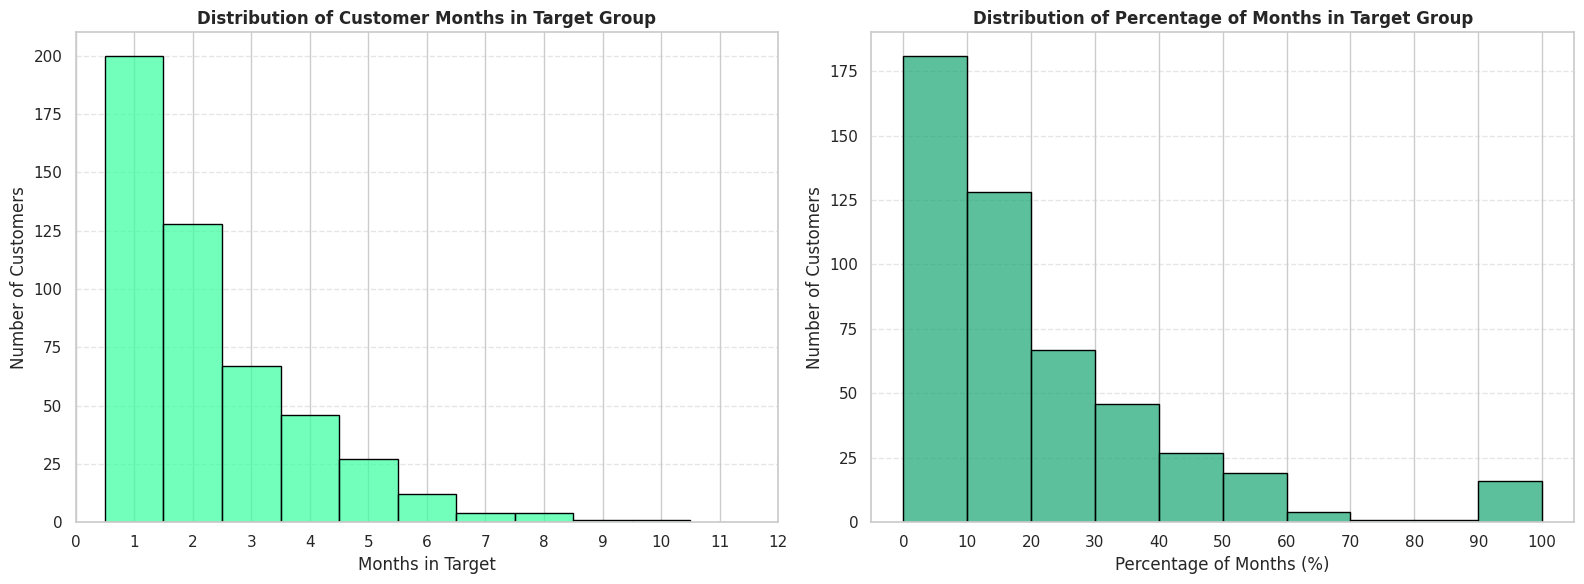

In [ ]:
# Absolute and relative distribution (excluding 0% group for the ratio plot)
# Initialize a canvas with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Histogram for months_in_target
sns.histplot(ax=axes[0], data=customer_target_stats[customer_target_stats['target_month_ratio'] > 0], x='months_in_target',
             discrete=True, color='#37ff9f', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Customer Months in Target Group', fontsize=12, weight='bold')
axes[0].set_xlabel('Months in Target')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xticks(range(0, 13))
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# 2. Histogram for target_month_ratio (excluding 0% group)
# Bins divided by 10% starting from just above 0 up to 100
bins_ratio = np.arange(0, 101, 10)
sns.histplot(ax=axes[1], data=customer_target_stats[customer_target_stats['target_month_ratio'] > 0], x='target_month_ratio',
             bins=bins_ratio, color='#18a674', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution of Percentage of Months in Target Group', fontsize=12, weight='bold')
axes[1].set_xlabel('Percentage of Months (%)')
axes[1].set_ylabel('Number of Customers')
axes[1].set_xticks(bins_ratio)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Customers with more than 60% of months in Target Group:


,consumer_id,months_in_target,total_months_recorded,target_month_ratio
33,KH00100685,1,1,100.000000
63,KH00101285,10,12,83.333333
71,KH00101445,8,12,66.666667
196,KH00103930,1,1,100.000000
216,KH00104330,1,1,100.000000
230,KH00104610,1,1,100.000000
272,KH00105450,1,1,100.000000
277,KH00105565,1,1,100.000000
313,KH00106285,1,1,100.000000
349,KH00107005,8,12,66.666667


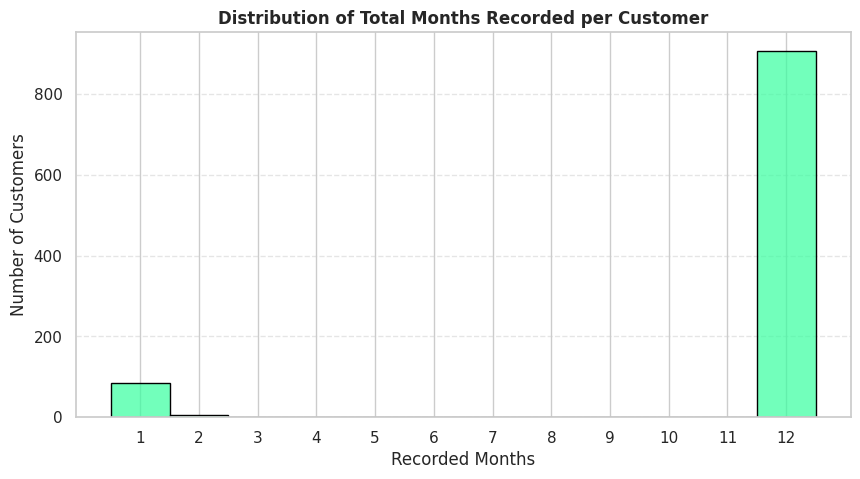

In [ ]:
# Detailed check for customers with more than 60% of months in the Target group
print("Customers with more than 60% of months in Target Group:")
display(customer_target_stats[customer_target_stats['target_month_ratio'] > 60])

# Plot histogram of total_months_recorded to check distribution of recorded months per customer
plt.figure(figsize=(10, 5))
sns.histplot(data=customer_target_stats, x='total_months_recorded', discrete=True, color='#37ff9f', edgecolor='black', alpha=0.7)
plt.title('Distribution of Total Months Recorded per Customer', fontsize=12, weight='bold')
plt.xlabel('Recorded Months')
plt.ylabel('Number of Customers')
plt.xticks(range(1, 13))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**Findings:**
- Đa số khách hàng tập chỉ có 1-3 tháng nằm trong nhóm High Health Low Engagement, và có dưới 30% số tháng ghi nhận được là nằm trong nhóm này. Điều này cho thấy đa phân chỉ là biến động tạm thời (một vài tháng health tạm cao + engagement tạm thấp do lý do ngẫu nhiên, không phải đặc điểm cố định)
- Dặc biệt nhóm có tỷ lệ này 100% toàn bộ đều chỉ có 1 tháng được ghi nhận, do đó đây không phải là hành vi ổn định cần xem xét.
- Quyết định: Loại bỏ nhóm chỉ có 1 và 2 tháng nằm trong nhóm High Health Low Engagement này để phân tích.

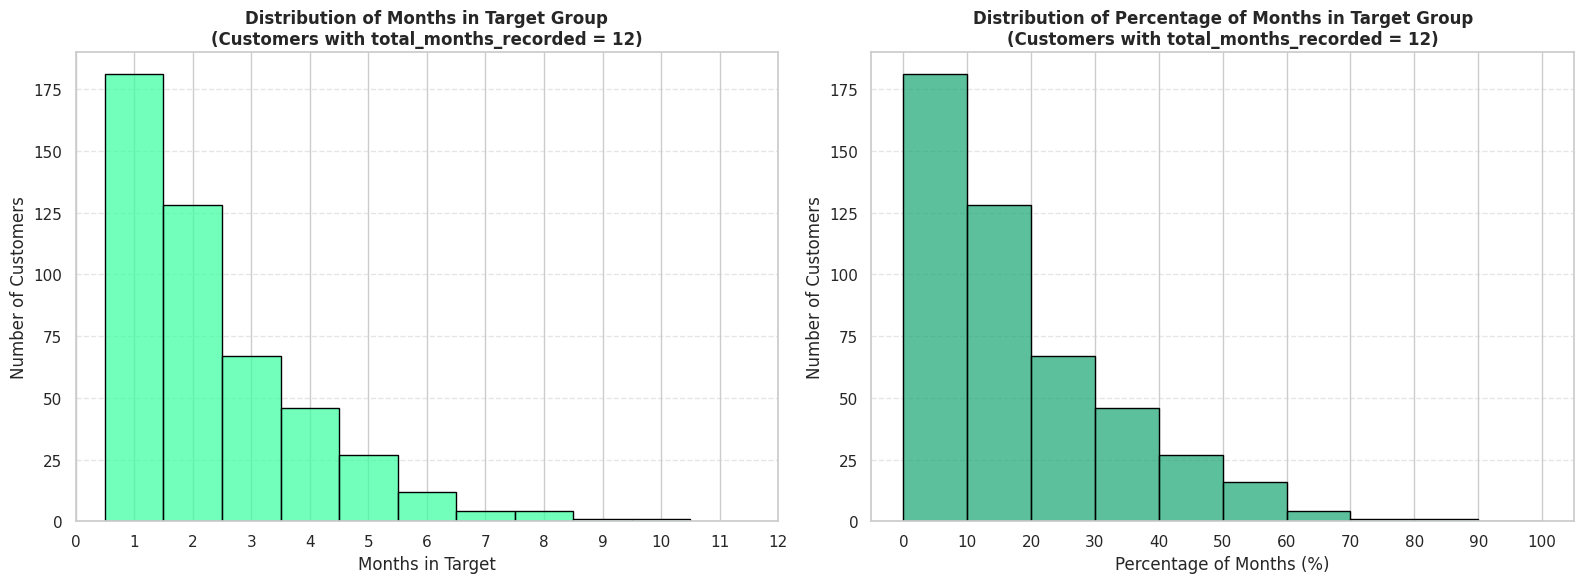

In [ ]:
# Filter customers with total recorded months = 12
df_filtered_target = customer_target_stats[customer_target_stats['total_months_recorded'] == 12]

# Initialize a canvas with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Histogram for months_in_target
sns.histplot(ax=axes[0], data=df_filtered_target[df_filtered_target['months_in_target'] > 0], x='months_in_target',
             discrete=True, color='#37ff9f', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Months in Target Group\n(Customers with total_months_recorded = 12)', fontsize=12, weight='bold')
axes[0].set_xlabel('Months in Target')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xticks(range(0, 13))
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# 2. Histogram for target_month_ratio
bins_ratio = np.arange(0, 101, 10)
sns.histplot(ax=axes[1], data=df_filtered_target[df_filtered_target['target_month_ratio'] > 0], x='target_month_ratio',
             bins=bins_ratio, color='#18a674', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution of Percentage of Months in Target Group\n(Customers with total_months_recorded = 12)', fontsize=12, weight='bold')
axes[1].set_xlabel('Percentage of Months (%)')
axes[1].set_ylabel('Number of Customers')
axes[1].set_xticks(bins_ratio)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Nhận xét:**
- Sau khi lọc ra dữ liệu nhiễu, 2 biểu đồ có dạng giống nhau hoàn hảo.
- Quyết định chọn ngưỡng để segment chia ra 2 nhóm khách hàng khác nhau: nhóm ngẫu nhiên (có ít tháng thuộc nhóm này, là hành vi ngẫu nhiên chứ không phải xu hướng) và nhóm Persistent (có số  tháng thuộc nhóm High Health Low Engagement đủ nhiều để xem là 1 hành vi cần quan tâm). Mốc chia: <=4 tháng (1/3 năm) thì xem là bình thường, từ 5 tháng trở lên thì xem là hành vi cần phân tích.
- Lý do chọn mốc này: Mốc 4 chia histogram ra làm 2 phần: phần bên trái dày, phần bên phải mỏng

In [ ]:
df_persistent_target = df_filtered_target[df_filtered_target['months_in_target'] > 4]

# Tính quy mô và tỷ lệ
persistent_size = len(df_persistent_target)
total_customers = customer_target_stats['consumer_id'].nunique()
persistent_ratio = (persistent_size / total_customers) * 100

print(f"Quy mô nhóm khách hàng Persistent Target:")
print(f"- Số lượng (Size): {persistent_size} khách hàng")
print(f"- Tỷ lệ trên tổng số khách hàng ({total_customers} KH): {persistent_ratio:.2f}%")

Quy mô nhóm khách hàng Persistent Target:
- Số lượng (Size): 49 khách hàng
- Tỷ lệ trên tổng số khách hàng (999 KH): 4.90%


**Note:** Khoảng 4.9% (49 khách hàng trên tổng số toàn bộ 999 khách hàng) thuộc nhóm Persistent này (có từ 5 tháng trở lên nằm trong nhóm High Health Low Engagement)

In [ ]:
# Phân tích Demographics của nhóm này
# Join với bảng ban đầu để lấy thông tin nhân khẩu học
df_persistent_demographics = df_persistent_target.merge(df_engagement, on = 'consumer_id', how = 'left')
df_persistent_demographics.drop(columns= ['analysis_month', 'months_in_target', 'total_months_recorded', 'target_month_ratio', 'credit_limit_vnd', 'opening_balance_vnd', 'ending_balance_vnd', 'essential_spend_vnd', 'discretionary_spend_vnd', 'online_spend_vnd', 'essential_spend_ratio', 'engagement_score', 'financial_health_score', 'engagement_segment', 'financial_health_segment', 'next_month_low_health_flag', 'is_low_engagement', 'is_high_financial_health', 'is_high_health_low_engage', 'log_transaction_count'], inplace = True)
print(df_persistent_demographics.shape)

(588, 17)


In [ ]:
# Trích Profile của nhóm Persistent High Health Low Engagement

# 1. Lấy thông tin cơ bản từ df_persistent_target kết hợp thông tin nhân khẩu học cơ bản
columns_engagement = ['consumer_id', 'age', 'gender', 'occupation', 'province_city']
df_persistent_base = df_persistent_demographics[columns_engagement].drop_duplicates(subset=['consumer_id']).reset_index(drop=True)

# 2. Lấy thông tin cá nhân bổ sung chi tiết từ df_transactions
personal_cols_in_trans = ['consumer_id', 'customer_name', 'date_of_birth', 'street_address', 'ward_commune', 'administrative_code']
df_trans_personal = df_transactions[personal_cols_in_trans].drop_duplicates(subset=['consumer_id'])

# 3. Thực hiện join thông tin chi tiết vào danh sách khách hàng Persistent
df_persistent_enriched = df_persistent_base.merge(df_trans_personal, on='consumer_id', how='left')

# 4. Sắp xếp lại các cột theo đúng định dạng chuẩn
final_columns = [
    'consumer_id', 'customer_name', 'gender', 'age', 'occupation',
    'province_city', 'date_of_birth', 'street_address', 'ward_commune', 'administrative_code'
]
df_persistent_enriched = df_persistent_enriched[final_columns]

# 5. Hiển thị thông tin quy mô và toàn bộ danh sách khách hàng mục tiêu thuộc nhóm Persistent
print(f"Tổng số khách hàng thuộc nhóm Persistent High Health Low Engagement: {len(df_persistent_enriched)} khách hàng")
display(df_persistent_enriched)

Tổng số khách hàng thuộc nhóm Persistent High Health Low Engagement: 49 khách hàng


,consumer_id,customer_name,gender,age,occupation,province_city,date_of_birth,street_address,ward_commune,administrative_code
0,KH00100890,Võ Hoài Linh,Nữ,65,Kỹ sư xây dựng dân dụng,Tây Ninh,1960-01-20,Số 139 đường Hai Bà Trưng,Bến Lức,72209
1,KH00101285,Ngô Đình Phong,Nam,69,Giám đốc vận hành,Thành phố Hồ Chí Minh,1956-03-31,Số 380 đường Nguyễn Du,Phú Nhuận,79605
2,KH00101445,Dương Thanh Ngọc,Nữ,33,Chuyên viên ngân hàng đầu tư vận hành,Nghệ An,1992-02-26,Số 240 đường Trần Hưng Đạo,Hưng Bình,40665
3,KH00101450,Trịnh Mỹ Hương,Nữ,57,Kỹ sư đóng tàu,Cần Thơ,1968-09-11,Số 247 đường Nguyễn Du,Vị Thanh,92705
4,KH00103525,Đào Ngọc Hải,Nam,47,Chuyên viên vệ sinh lao động,Hà Nội,1978-10-09,Số 322 đường Lê Lợi,Thanh Xuân,1905
5,KH00104690,Nguyễn Thanh Nga,Nữ,68,Nhà tâm lý học giáo dục,Đồng Tháp,1957-05-26,Số 1 đường Lý Thường Kiệt,Phường 2,87483
6,KH00104890,Đào Thanh Thảo,Nữ,60,Kỹ sư khai thác mỏ,Đắk Lắk,1965-01-06,Số 179 đường Cao Thắng,Ea Kar,66737
7,KH00105410,Bùi Diễm Oanh,Nữ,55,Chuyên viên công nghệ màu sắc,Hà Nội,1970-11-21,Số 213 đường Cao Thắng,Nam Từ Liêm,1307
8,KH00105725,Trần Ngọc Phong,Nam,53,Luật sư sáng chế,Nghệ An,1972-01-12,Số 42 đường Lê Lợi,Vinh Tân,40195
9,KH00105890,Lê Công Hoàng,Nam,37,Kỹ sư phát thanh truyền hình,Cần Thơ,1988-01-21,Số 151 đường Bà Triệu,Bình Thủy,92998


In [ ]:
# Lấy dữ liệu của nhóm Rest (còn lại)
df_rest_target = df_filtered_target[~df_filtered_target['consumer_id'].isin(df_persistent_target['consumer_id'])]
df_rest_demographics = df_rest_target.merge(df_engagement, on = 'consumer_id', how = 'left')
df_rest_demographics.drop(columns = ['analysis_month', 'months_in_target', 'total_months_recorded', 'target_month_ratio', 'credit_limit_vnd', 'opening_balance_vnd', 'ending_balance_vnd', 'essential_spend_vnd', 'discretionary_spend_vnd', 'online_spend_vnd', 'essential_spend_ratio', 'engagement_score', 'financial_health_score', 'engagement_segment', 'financial_health_segment', 'next_month_low_health_flag', 'is_low_engagement', 'is_high_financial_health', 'is_high_health_low_engage', 'log_transaction_count'], inplace = True)
print(df_rest_demographics.shape)


(10308, 17)


- Bắt đầu so sánh đặc điểm giữa 2 nhóm Persistent và Rest bằng cách:
1. Gộp lại chỉ còn 1 dòng / khách hàng, giữ nguyên các thuộc tính về demographiscs và các thuộc tính numeric thì dùng avg/median tùy vào phân phối.
2. So sánh các thuộc tính về nhân khẩu học và hành vi tài chính



In [ ]:
# Xác định danh sách các cột cần áp dụng các phép toán gộp (aggregation)
# Các cột nhân khẩu học phi số (hoặc số cố định như age) sẽ lấy giá trị đầu tiên (first)
demographic_cols = ['age', 'gender', 'occupation', 'province_city']

# Xác định các cột numeric cần tính mean và median
median_cols = ['active_transaction_days', 'category_diversity', 'transaction_recency_days']

def aggregate_customer_demographics(df):
    # Tìm tất cả các cột numeric hiện có trong DataFrame
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    # Loại bỏ các cột thuộc nhóm median_cols và consumer_id khỏi danh sách tính mean
    mean_cols = [col for col in numeric_cols if col not in median_cols and col != 'consumer_id' and col not in demographic_cols]

    # Khởi tạo dictionary chứa các hàm aggregation
    agg_dict = {}

    # 1. Với các cột nhân khẩu học dạng phân loại/phân định
    for col in df.columns:
        if col in demographic_cols and col in df.columns:
            agg_dict[col] = 'first'

    # 2. Với các cột tính median theo yêu cầu
    for col in median_cols:
        if col in df.columns:
            agg_dict[col] = 'median'

    # 3. Với các cột numeric còn lại tính mean
    for col in mean_cols:
        agg_dict[col] = 'mean'

    # Tiến hành Groupby theo consumer_id
    df_aggregated = df.groupby('consumer_id').agg(agg_dict).reset_index()
    return df_aggregated

# Thực hiện gộp dữ liệu cho cả 2 nhóm
df_persistent_customer = aggregate_customer_demographics(df_persistent_demographics)
df_rest_customer = aggregate_customer_demographics(df_rest_demographics)

# Kiểm tra kích thước và hiển thị dữ liệu mẫu
print("Kích thước tệp Persistent sau khi gộp:", df_persistent_customer.shape)
print("Kích thước tệp Rest sau khi gộp:", df_rest_customer.shape)

print("\nVí dụ 5 dòng đầu của nhóm Persistent:")
display(df_persistent_customer.head())


Kích thước tệp Persistent sau khi gộp: (49, 17)
Kích thước tệp Rest sau khi gộp: (859, 17)

Ví dụ 5 dòng đầu của nhóm Persistent:


,consumer_id,age,gender,occupation,province_city,active_transaction_days,category_diversity,transaction_recency_days,monthly_income_vnd,total_spend_vnd,transaction_count,average_transaction_value_vnd,discretionary_spend_ratio,online_spend_ratio,spend_to_income_ratio,credit_utilization_ratio,spending_volatility
0,KH00100890,65,Nữ,Kỹ sư xây dựng dân dụng,Tây Ninh,25.0,13.0,0.0,1.420258e+08,1.025182e+08,61.500000,1.627547e+06,0.462672,0.187937,0.720467,0.148892,1.580648
1,KH00101285,69,Nam,Giám đốc vận hành,Thành phố Hồ Chí Minh,26.0,13.0,0.0,3.110150e+08,9.317500e+07,61.166667,1.559407e+06,0.415708,0.163364,0.300883,0.061833,1.191049
2,KH00101445,33,Nữ,Chuyên viên ngân hàng đầu tư vận hành,Nghệ An,26.0,14.0,0.0,1.734442e+08,8.525275e+07,61.083333,1.324573e+06,0.400538,0.122110,0.492025,0.158192,1.254657
3,KH00101450,57,Nữ,Kỹ sư đóng tàu,Cần Thơ,24.0,13.0,0.0,1.717783e+08,1.001579e+08,61.083333,1.696169e+06,0.470827,0.168618,0.586483,0.135017,1.278617
4,KH00103525,47,Nam,Chuyên viên vệ sinh lao động,Hà Nội,26.0,14.0,0.0,1.165625e+08,1.347756e+08,61.500000,2.097060e+06,0.465393,0.160185,1.146367,0.276667,1.781848


In [ ]:
# So sánh Nhân khẩu học giữa 2 nhóm Persistent và Rest

# 1. So sánh độ tuổi (Age)
age_summary = pd.DataFrame({
    'Nhóm': ['Persistent', 'Rest'],
    'Average': [df_persistent_customer['age'].mean(), df_rest_customer['age'].mean()],
    'Median': [df_persistent_customer['age'].median(), df_rest_customer['age'].median()],
    'Min': [df_persistent_customer['age'].min(), df_rest_customer['age'].min()],
    'Max': [df_persistent_customer['age'].max(), df_rest_customer['age'].max()]
})

print("1. SO SÁNH ĐỘ TUỔI (AGE)")
display(age_summary.round(2))
print("\n")

# 2. So sánh Giới tính (Gender)
gender_p = df_persistent_customer['gender'].value_counts(normalize=True) * 100
gender_r = df_rest_customer['gender'].value_counts(normalize=True) * 100
gender_comparison = pd.DataFrame({
    'Persistent (%)': gender_p,
    'Rest (%)': gender_r
}).fillna(0)

print("2. SO SÁNH GIỚI TÍNH (GENDER)")
display(gender_comparison.round(2))
print("\n")

# 3. So sánh Top 5 Nghề nghiệp (Occupation)
occ_p = df_persistent_customer['occupation'].value_counts(normalize=True) * 100
occ_r = df_rest_customer['occupation'].value_counts(normalize=True) * 100
occ_comparison = pd.DataFrame({
    'Persistent (%)': occ_p,
    'Rest (%)': occ_r
}).fillna(0)


1. SO SÁNH ĐỘ TUỔI (AGE)


,Nhóm,Average,Median,Min,Max
0,Persistent,53.16,54.0,16,93
1,Rest,49.00,47.0,15,96




2. SO SÁNH GIỚI TÍNH (GENDER)


,Persistent (%),Rest (%)
gender,,
Nữ,51.02,50.64
Nam,48.98,49.36


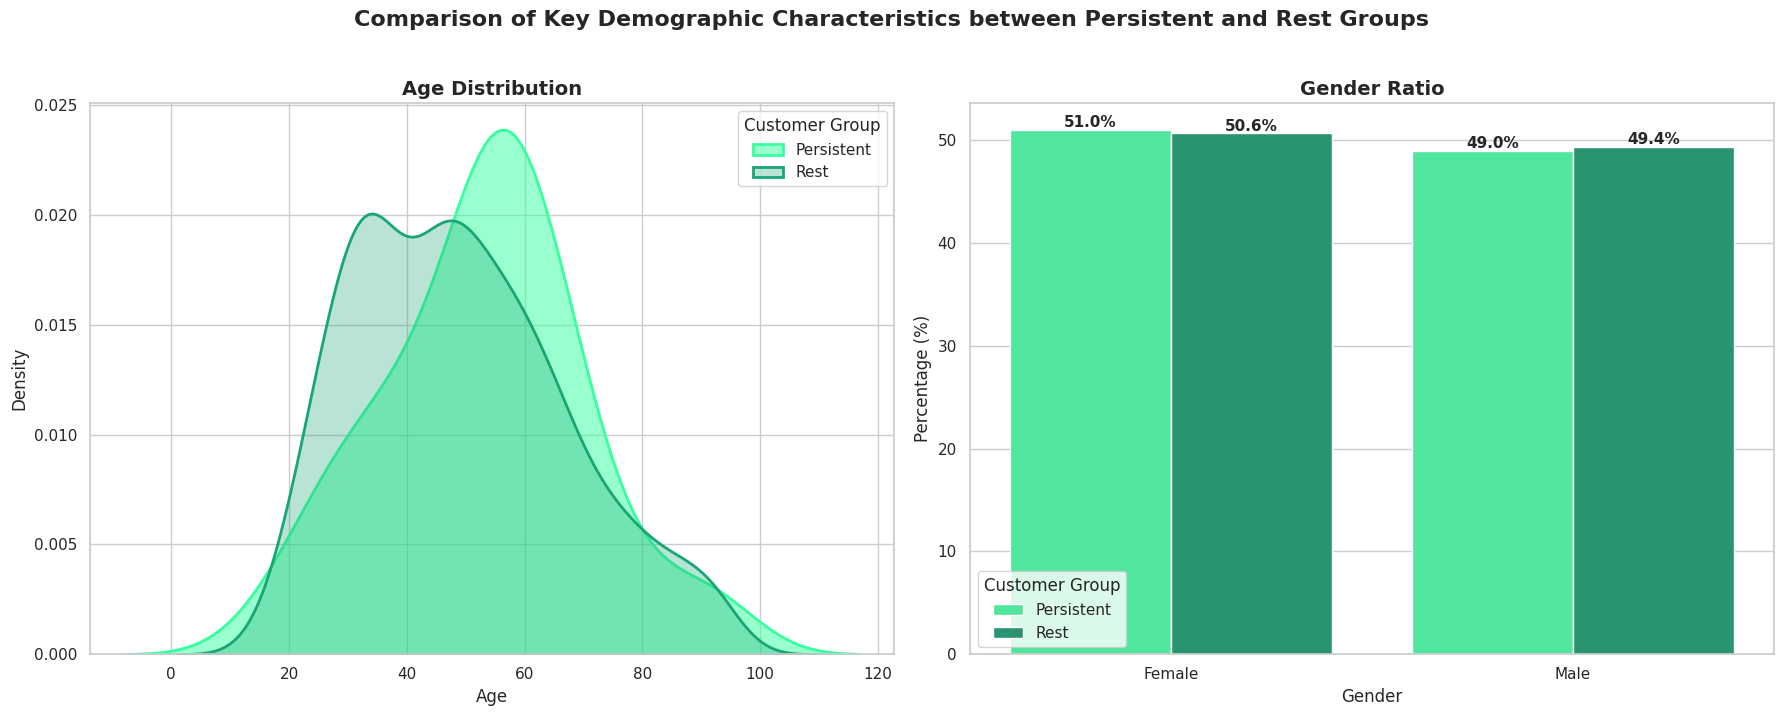

In [ ]:
# Visualization
# Set style and font for charts
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Age Distribution Chart
sns.kdeplot(ax=axes[0], data=df_persistent_customer, x='age', label='Persistent', fill=True, color='#37ff9f', alpha=0.5, linewidth=2)
sns.kdeplot(ax=axes[0], data=df_rest_customer, x='age', label='Rest', fill=True, color='#18a674', alpha=0.3, linewidth=2)
axes[0].set_title('Age Distribution', fontsize=14, weight='bold')
axes[0].set_xlabel('Age', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].legend(title='Customer Group', fontsize=11)

# 2. Gender Ratio Chart
gender_df = gender_comparison.reset_index().melt(id_vars='gender', var_name='Nhóm', value_name='Tỷ lệ (%)')
# Map Vietnamese group labels and gender labels to English labels for consistent display
gender_df['Nhóm'] = gender_df['Nhóm'].replace({'Persistent (%)': 'Persistent', 'Rest (%)': 'Rest'})
gender_df['gender'] = gender_df['gender'].replace({'Nam': 'Male', 'Nữ': 'Female'})

sns.barplot(ax=axes[1], data=gender_df, x='gender', y='Tỷ lệ (%)', hue='Nhóm', palette=['#37ff9f', '#18a674'])
axes[1].set_title('Gender Ratio', fontsize=14, weight='bold')
axes[1].set_xlabel('Gender', fontsize=12)
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].legend(title='Customer Group', fontsize=11)

# Annotate percentages on bars
for p in axes[1].patches:
    height = p.get_height()
    if height > 0:
        axes[1].annotate(f'{height:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    xytext=(0, 5),
                    textcoords='offset points', fontsize=11, weight='bold')

plt.suptitle('Comparison of Key Demographic Characteristics between Persistent and Rest Groups', fontsize=16, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Về các yếu tố nhân khẩu học:**
- Nhân khẩu học không phải là yếu tố phân biệt mạnh vì:
1. Gender không có khác biệt
2. Age có xu hướng lớn tuổi hơn (~4-6 tuổi tùy vào xem average hay median) nhưng cũng không quá cách biệt
3. Occupation quá loãng (có quá nhiều occupation, không có xu hướng cụ thể) để so sánh
4. Province City cũng không có xu hướng rõ rệt

In [ ]:
# So sánh hành vi tài chính
# 1. Xác định các cột numeric cần so sánh
numeric_cols_to_compare = df_persistent_customer.select_dtypes(include=[np.number]).columns.tolist()
for col in ['consumer_id', 'age']:
    if col in numeric_cols_to_compare:
        numeric_cols_to_compare.remove(col)

# 2. Tính giá trị trung bình của từng cột cho cả 2 nhóm
persistent_means = df_persistent_customer[numeric_cols_to_compare].mean()
rest_means = df_rest_customer[numeric_cols_to_compare].mean()

# 3. Tạo DataFrame so sánh
df_comparison = pd.DataFrame({
    'Chỉ số (average)': numeric_cols_to_compare,
    'Persistent': persistent_means.values,
    'Rest': rest_means.values
})

# 4. Tính chênh lệch phần trăm (% Difference)
# Công thức: ((Persistent - Rest) / Rest) * 100
df_comparison['Chênh lệch (%)'] = ((df_comparison['Persistent'] - df_comparison['Rest']) / df_comparison['Rest']) * 100

# Định dạng lại hiển thị cho dễ đọc
df_comparison['Chênh lệch (%)'] = df_comparison['Chênh lệch (%)'].map('{:+.2f}%'.format)

# Sắp xếp các cột số tiền cho đẹp
for col in ['Persistent', 'Rest']:
    df_comparison[col] = df_comparison[col].map(lambda x: f"{x:,.2f}" if x > 100 else f"{x:.4f}")

display(df_comparison)

,Chỉ số (average),Persistent,Rest,Chênh lệch (%)
0,active_transaction_days,26.0408,29.3661,-11.32%
1,category_diversity,13.3265,13.8650,-3.88%
2,transaction_recency_days,0.0000,0.0000,+nan%
3,monthly_income_vnd,"215,116,989.80","465,122,500.00",-53.75%
4,total_spend_vnd,"121,746,787.41","306,488,922.68",-60.28%
5,transaction_count,68.8741,175.69,-60.80%
6,average_transaction_value_vnd,"1,778,616.41","1,763,482.39",+0.86%
7,discretionary_spend_ratio,0.4874,0.5180,-5.92%
8,online_spend_ratio,0.1862,0.2075,-10.28%
9,spend_to_income_ratio,0.5966,0.7061,-15.51%


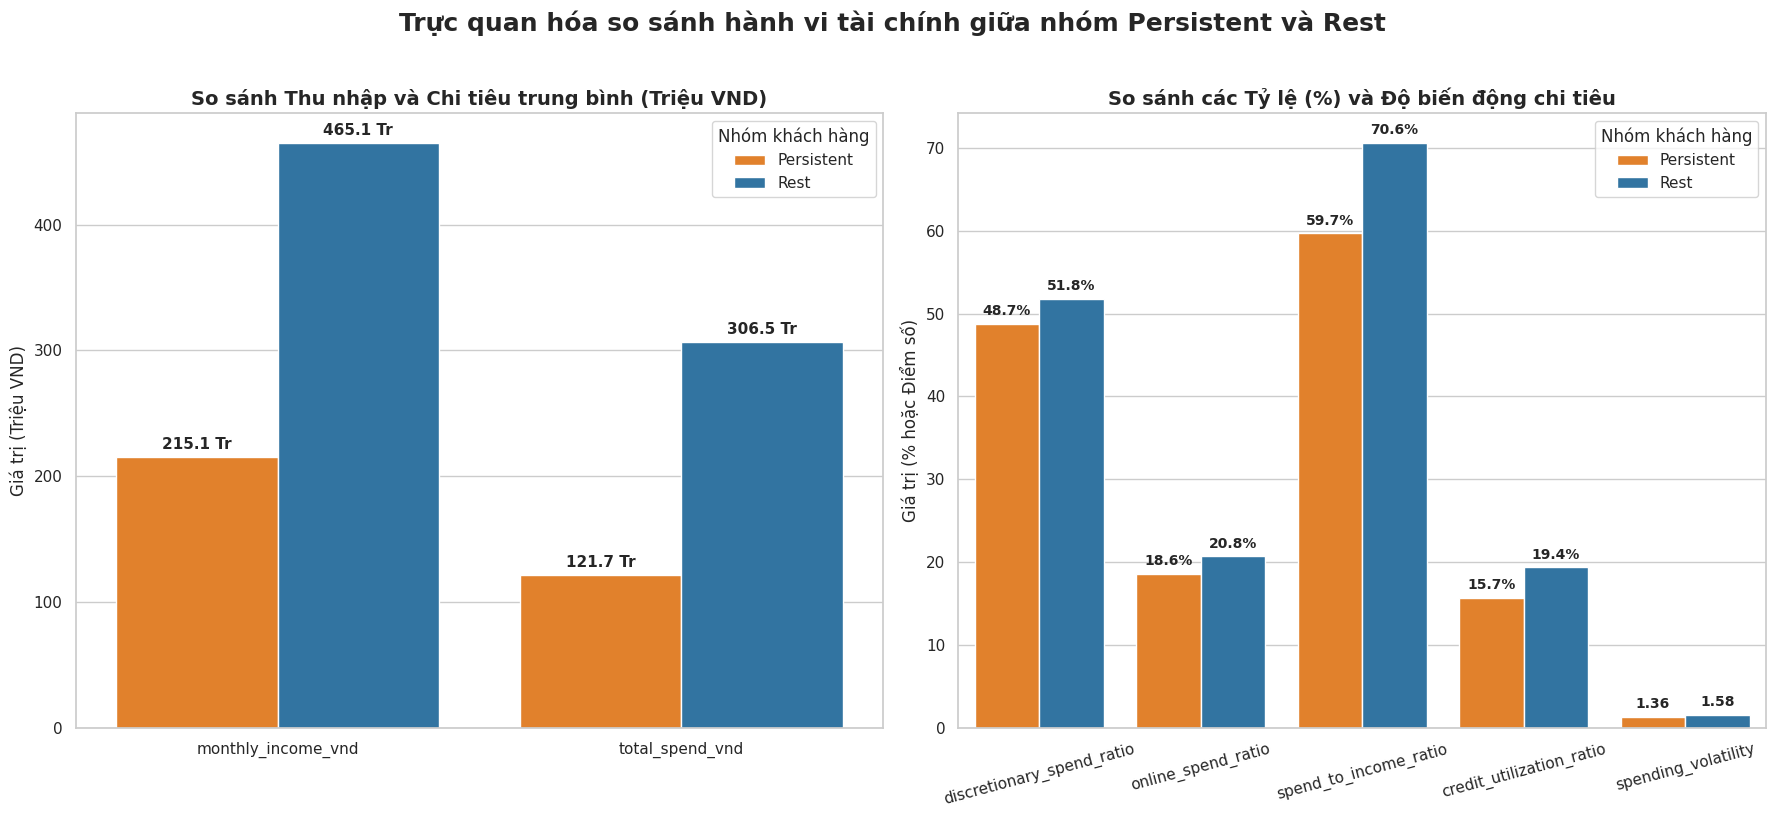

In [ ]:
# Trực quan hóa
# Thiết lập style cho biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'

# Chuẩn bị lại dữ liệu thô (giữ nguyên tên biến gốc)
persistent_raw = df_persistent_customer[numeric_cols_to_compare].mean()
rest_raw = df_rest_customer[numeric_cols_to_compare].mean()

df_plot = pd.DataFrame({
    'Chỉ số': numeric_cols_to_compare,
    'Persistent': persistent_raw.values,
    'Rest': rest_raw.values
})

# Tạo figure với 2 subplots nằm ngang
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Biểu đồ 1: So sánh Thu nhập & Chi tiêu (giữ nguyên tên biến gốc, đơn vị quy đổi sang Triệu VND để vẽ trực quan) ---
financial_metrics = ['monthly_income_vnd', 'total_spend_vnd']
df_fin = df_plot[df_plot['Chỉ số'].isin(financial_metrics)].copy()

# Đổi giá trị sang đơn vị triệu VND để hiển thị biểu đồ trực quan
df_fin['Persistent'] = df_fin['Persistent'] / 1e6
df_fin['Rest'] = df_fin['Rest'] / 1e6

# Melt dataframe để vẽ bằng seaborn
df_fin_melted = df_fin.melt(id_vars='Chỉ số', value_vars=['Persistent', 'Rest'],
                            var_name='Nhóm khách hàng', value_name='Giá trị (Triệu VND)')

sns.barplot(ax=axes[0], data=df_fin_melted, x='Chỉ số', y='Giá trị (Triệu VND)', hue='Nhóm khách hàng', palette=['#ff7f0e', '#1f77b4'])
axes[0].set_title('So sánh Thu nhập và Chi tiêu trung bình (Triệu VND)', fontsize=14, weight='bold')
axes[0].set_ylabel('Giá trị (Triệu VND)', fontsize=12)
axes[0].set_xlabel('', fontsize=12)
for p in axes[0].patches:
    height = p.get_height()
    if height > 0:
        axes[0].annotate(f'{height:,.1f} Tr',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points', fontsize=11, weight='bold')

# --- Biểu đồ 2: So sánh các tỷ lệ và chỉ số hành vi (giữ nguyên tên biến gốc, nhân 100 với các biến tỷ lệ) ---
ratio_metrics = ['discretionary_spend_ratio', 'online_spend_ratio', 'spend_to_income_ratio', 'credit_utilization_ratio', 'spending_volatility']
df_ratio = df_plot[df_plot['Chỉ số'].isin(ratio_metrics)].copy()

# Quy đổi các cột tỷ lệ sang phần trăm (%), giữ nguyên độ biến động chi tiêu
for col in ['Persistent', 'Rest']:
    df_ratio.loc[df_ratio['Chỉ số'] != 'spending_volatility', col] = df_ratio.loc[df_ratio['Chỉ số'] != 'spending_volatility', col] * 100

df_ratio_melted = df_ratio.melt(id_vars='Chỉ số', value_vars=['Persistent', 'Rest'],
                              var_name='Nhóm khách hàng', value_name='Giá trị')

sns.barplot(ax=axes[1], data=df_ratio_melted, x='Chỉ số', y='Giá trị', hue='Nhóm khách hàng', palette=['#ff7f0e', '#1f77b4'])
axes[1].set_title('So sánh các Tỷ lệ (%) và Độ biến động chi tiêu', fontsize=14, weight='bold')
axes[1].set_ylabel('Giá trị (% hoặc Điểm số)', fontsize=12)
axes[1].set_xlabel('', fontsize=12)
axes[1].tick_params(axis='x', labelrotation=15)

for p in axes[1].patches:
    height = p.get_height()
    if height > 0:
        # Xác định nếu là nhãn của cột spending_volatility thì không hiển thị dấu %
        is_volatility = p.get_x() > 3.2
        label = f'{height:.2f}' if is_volatility else f'{height:.1f}%'
        axes[1].annotate(label,
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points', fontsize=10, weight='bold')

plt.suptitle('Trực quan hóa so sánh hành vi tài chính giữa nhóm Persistent và Rest', fontsize=18, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Về hành vi tài chính:**
- Có pattern rõ ràng, cụ thể hơn và phù hợp để phân biệt giữa 2 nhóm này hơn. Cụ thể:
1. Thu nhập thấp hơn đáng kể ở nhóm Persistent (-53.75%), tổng chi tiêu thấp hơn nhiều (-60.28%). Đây là nhóm năng lực và quy mô tài chính nhỏ hơn, không phải nhóm giàu có.
2. transaction_count thấp hơn nhiều (-60.80%) trong khi active_transaction_days chỉ giảm nhẹ (-11.32%) => họ vẫn giao dịch mặt đều đặn (không giảm mạnh về recency/active days) nhưng tần suất giao dịch mỗi lần dùng thẻ thấp hơn rất nhiều.
3. average_transaction_value_vnd không có sự khác biệt cho thấy họ chi tiêu bình thường mỗi lần dùng thẻ, chỉ là dùng ít lần hơn
4. spend_to_income_ratio thấp hơn (-15.51%) và credit_utilization_ratio thấp (-19.10%) => họ chi tiêu/dùng tín dụng thận trọng, dùng ít hơn so với khả năng cho phép, cho thấy hành vi quản lý tài chính ưu tiên sự an toàn
5. spending_volatility thấp hơn (-14.2%) cho thấy chi tiêu ổn định, dễ dự đoán, càng củng cố hình ảnh khách hàng thận trọng, có kỷ luật tài chính

**Profile tổng hợp cho nhóm Persistent High Health Low Engagement: (Nhờ Claude tổng hợp hehe)**
- Đây là nhóm khách hàng ưu tiên sự an toàn về tài chính nhưng chưa khai thác hết tiềm năng sử dụng thẻ. Họ không phải một phân khúc nhân khẩu học riêng biệt, mà là một kiểu hành vi tài chính đặc trưng:
1. Kỷ luật tài chính vững vàng: họ chi tiêu và sử dụng tín dụng ở mức thấp hơn hẳn khả năng cho phép, thể hiện phong cách quản lý tiền bạc thận trọng, có tính toán
2. Giao dịch đều đặn mỗi ngày: họ vẫn giao dịch mỗi ngày trong tháng với tần suất ổn định (active days gần như không khác biệt so với nhóm khác), cho thấy chiếc thẻ luôn nằm trong ví, sẵn sàng được dùng nhiều hơn
3. Xem thẻ với vai trò người bạn đồng hành phụ: quy mô tài chính (thu nhập, tổng chi tiêu) nhỏ hơn đáng kể phần còn lại, giá trị mỗi giao dịch cũng nhỏ đáng kể, cho thấy chiếc thẻ đang đóng vai trò công cụ dự phòng, đứng bên cạnh những phương thức chi tiêu chính khác trong cuộc sống hàng ngày của họ.

=> Đây là nhóm khách hàng có sức khỏe tài chính tốt và dư địa tăng trưởng lớn, họ có nền tảng vững, chỉ là họ chưa xem việc sử dụng thẻ là phương thức chi tiêu chủ yếu của mình. Do đó cần phải tạo ra đúng tác động phù hợp để chuyển từ người dùng thụ động sang người dùng tích cực.

,spending_category,transaction_count,total_spend_vnd
0,Chăm sóc cá nhân,2934,3613958000
1,Du lịch,1331,5449556000
2,Dịch vụ trực tuyến khác,2030,4276674000
3,Giải trí,2957,4178314000
4,Mua sắm khác tại cửa hàng,2291,3252701000
5,Mua sắm trực tuyến,2834,6327967000
6,Mua sắm tại cửa hàng,3386,6431289000
7,Nhà cửa và tiện ích,3879,5443930000
8,Siêu thị và tạp hóa tại cửa hàng,4082,11800457000
9,Sức khỏe và thể thao,2765,3556715000


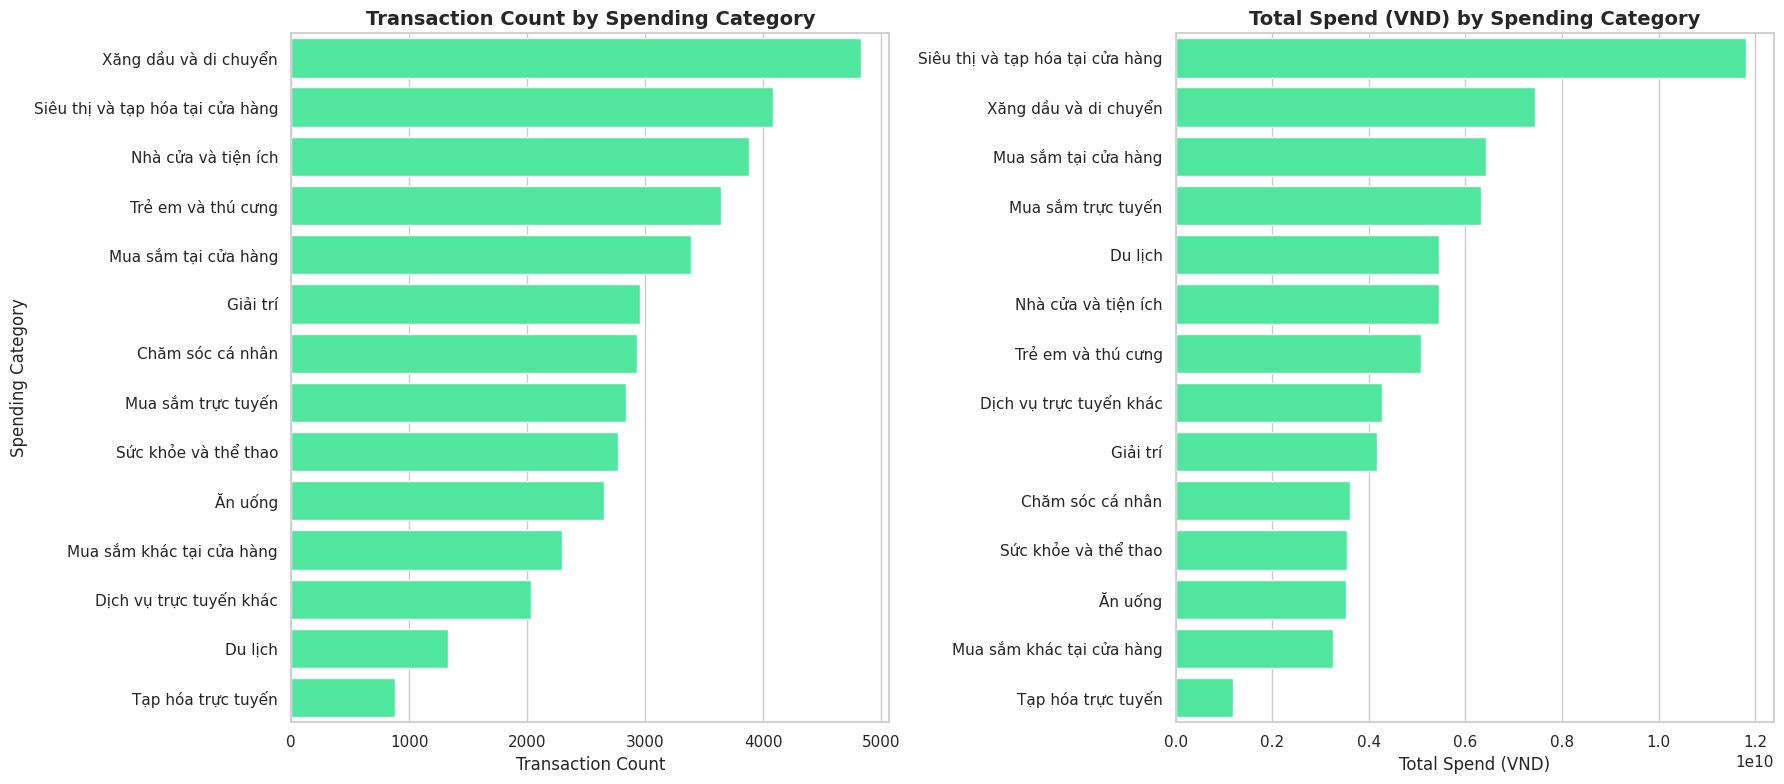

In [ ]:
# 1. Lọc giao dịch của 49 khách hàng thuộc nhóm persistent
persistent_ids = df_persistent_enriched['consumer_id'].unique()
df_persistent_transactions = df_transactions[df_transactions['consumer_id'].isin(persistent_ids)]

# 2. Thống kê theo đúng yêu cầu (giữ nguyên tên biến tiếng Anh, không đổi sang tiếng Việt)
category_stats = df_persistent_transactions.groupby('spending_category').agg(
    transaction_count=('transaction_id', 'count'),
    total_spend_vnd=('spend_amount_vnd', 'sum')
).reset_index()

# Hiển thị bảng số liệu
display(category_stats)

# 3. Vẽ 2 biểu đồ cột thể hiện transaction_count và total_spend_vnd theo spending_category (sắp xếp giảm dần)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Chuẩn bị dữ liệu sắp xếp riêng cho từng biểu đồ để đảm bảo hiển thị giảm dần hoàn hảo
stats_by_count = category_stats.sort_values(by='transaction_count', ascending=False)
stats_by_spend = category_stats.sort_values(by='total_spend_vnd', ascending=False)

# Biểu đồ 1: transaction_count theo spending_category
sns.barplot(
    ax=axes[0],
    x='transaction_count',
    y='spending_category',
    data=stats_by_count,
    order=stats_by_count['spending_category'],
    color='#37ff9f'
)
axes[0].set_title('Transaction Count by Spending Category', fontsize=14, weight='bold')
axes[0].set_xlabel('Transaction Count')
axes[0].set_ylabel('Spending Category')

# Biểu đồ 2: total_spend_vnd theo spending_category
sns.barplot(
    ax=axes[1],
    x='total_spend_vnd',
    y='spending_category',
    data=stats_by_spend,
    order=stats_by_spend['spending_category'],
    color='#37ff9f'
)
axes[1].set_title('Total Spend (VND) by Spending Category', fontsize=14, weight='bold')
axes[1].set_xlabel('Total Spend (VND)')
axes[1].set_ylabel('')  # Ẩn nhãn trục Y ở biểu đồ thứ 2 để tránh trùng lặp

plt.tight_layout()
plt.show()

,transaction_channel,transaction_count,total_spend_vnd
0,E-commerce,3168,6580788000
1,Mobile App,2845,4847381000
2,POS,24263,41820047000
3,QR Payment,8332,15157384000
4,Recurring Payment,1890,3181511000


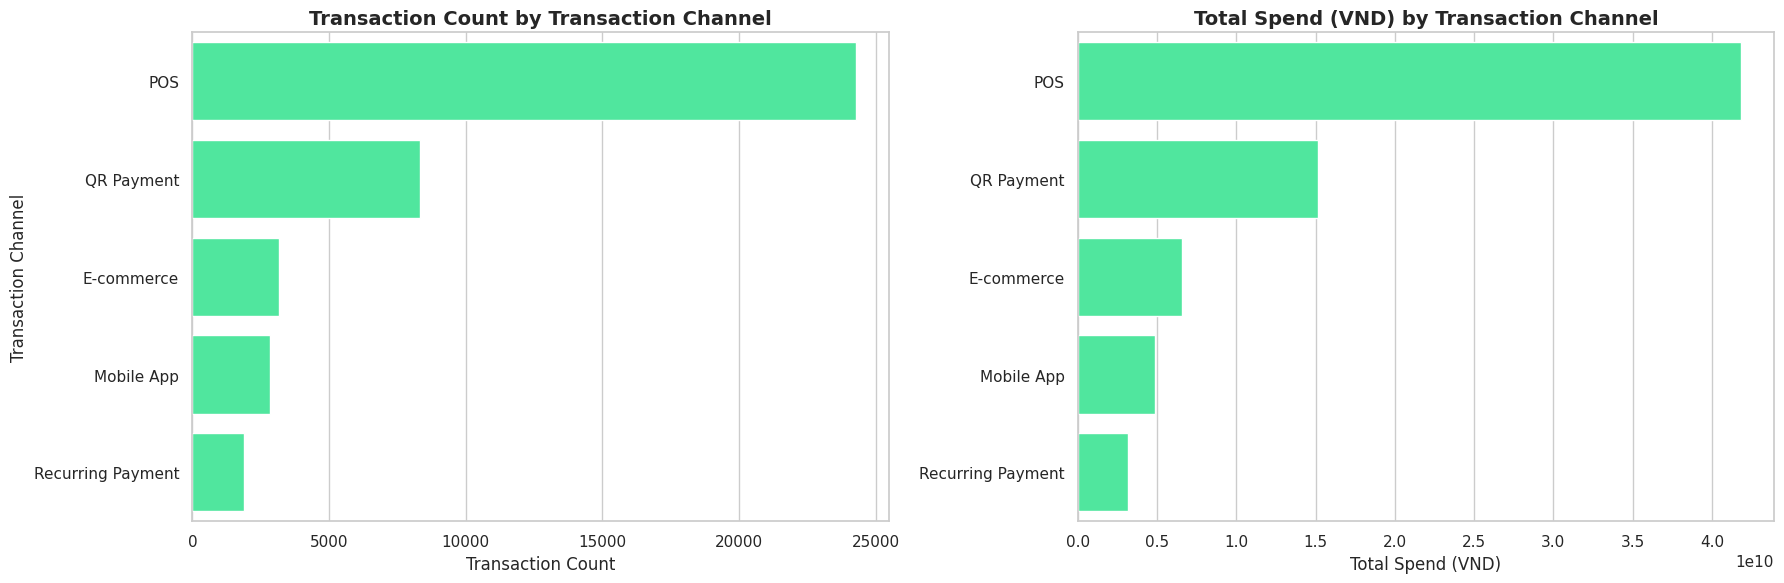

In [ ]:
# 1. Thống kê theo transaction_channel (giữ nguyên tên biến tiếng Anh)
channel_stats = df_persistent_transactions.groupby('transaction_channel').agg(
    transaction_count=('transaction_id', 'count'),
    total_spend_vnd=('spend_amount_vnd', 'sum')
).reset_index()

# Hiển thị bảng số liệu
display(channel_stats)

# 2. Vẽ 2 biểu đồ cột thể hiện transaction_count và total_spend_vnd theo transaction_channel (sắp xếp giảm dần)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Sắp xếp dữ liệu riêng cho từng biểu đồ để đảm bảo hiển thị thứ tự giảm dần chính xác
channel_by_count = channel_stats.sort_values(by='transaction_count', ascending=False)
channel_by_spend = channel_stats.sort_values(by='total_spend_vnd', ascending=False)

# Biểu đồ 1: transaction_count theo transaction_channel
sns.barplot(
    ax=axes[0],
    x='transaction_count',
    y='transaction_channel',
    data=channel_by_count,
    order=channel_by_count['transaction_channel'],
    color='#37ff9f'
)
axes[0].set_title('Transaction Count by Transaction Channel', fontsize=14, weight='bold')
axes[0].set_xlabel('Transaction Count')
axes[0].set_ylabel('Transaction Channel')

# Biểu đồ 2: total_spend_vnd theo transaction_channel
sns.barplot(
    ax=axes[1],
    x='total_spend_vnd',
    y='transaction_channel',
    data=channel_by_spend,
    order=channel_by_spend['transaction_channel'],
    color='#37ff9f'
)
axes[1].set_title('Total Spend (VND) by Transaction Channel', fontsize=14, weight='bold')
axes[1].set_xlabel('Total Spend (VND)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

,spending_category,transaction_count,total_spend_vnd
0,Chăm sóc cá nhân,8,4056000
1,Du lịch,10,2615000
2,Dịch vụ trực tuyến khác,69,1404086000
3,Giải trí,6,60670000
4,Mua sắm khác tại cửa hàng,14,2848000
5,Mua sắm trực tuyến,133,3313436000
6,Mua sắm tại cửa hàng,57,1413679000
7,Nhà cửa và tiện ích,2,12032000
8,Siêu thị và tạp hóa tại cửa hàng,114,852892000
9,Trẻ em và thú cưng,4,2089000


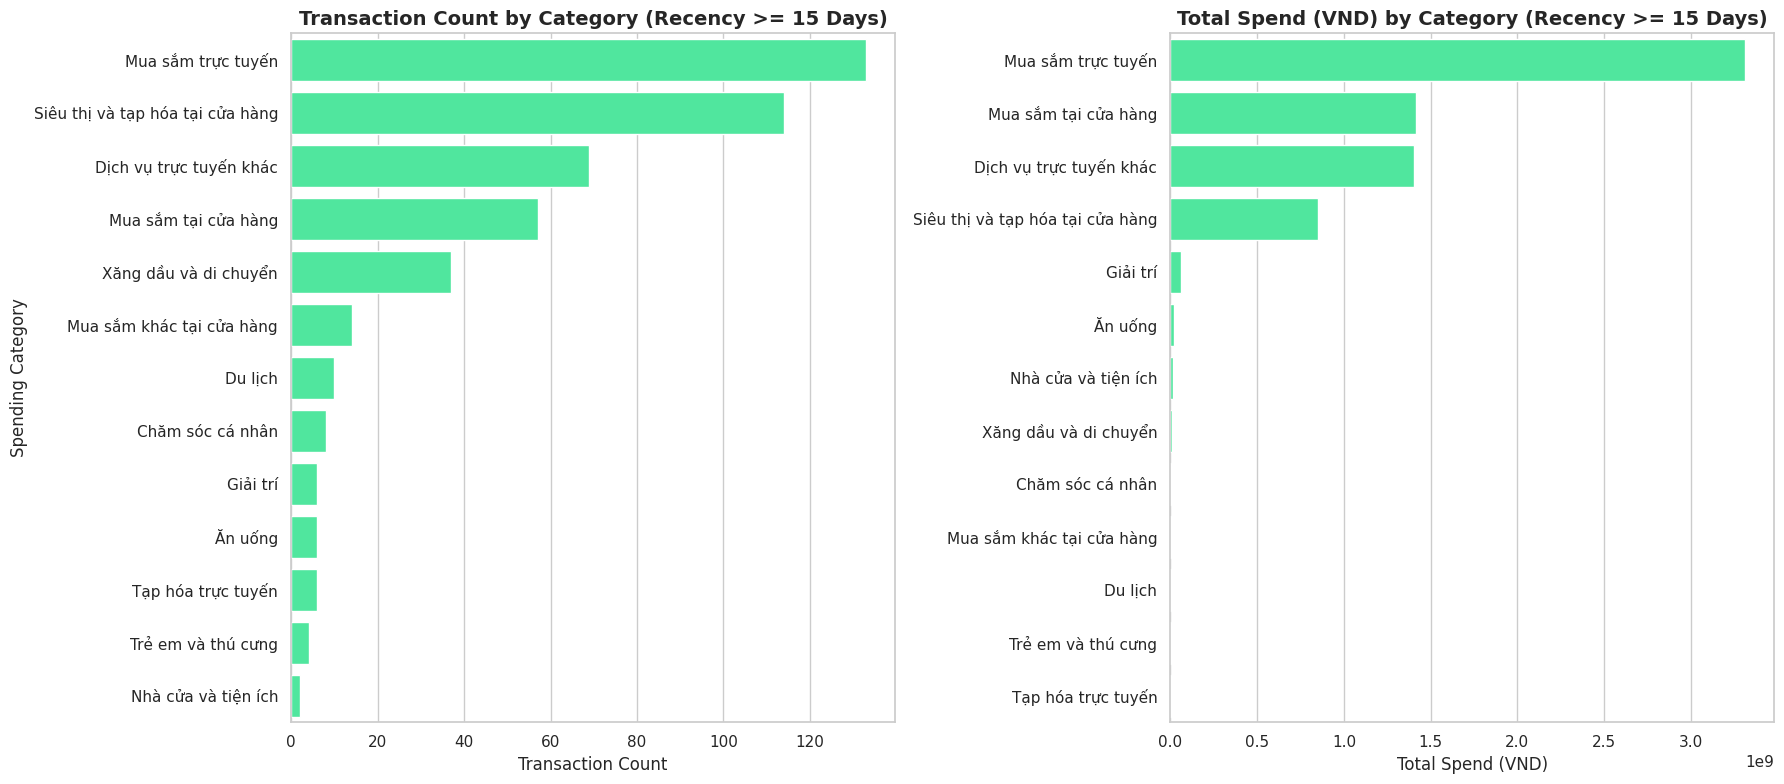

In [ ]:
# 1. Lọc danh sách khách hàng có transaction_recency_days >= 15 từ df_engagement
recency_customer_ids = df_engagement[df_engagement['transaction_recency_days'] >= 15]['consumer_id'].unique()

# 2. Lọc các giao dịch tương ứng của các khách hàng này từ df_transactions
df_recency_transactions = df_transactions[df_transactions['consumer_id'].isin(recency_customer_ids)]

# 3. Thống kê theo spending_category (giữ nguyên tên biến tiếng Anh)
recency_category_stats = df_recency_transactions.groupby('spending_category').agg(
    transaction_count=('transaction_id', 'count'),
    total_spend_vnd=('spend_amount_vnd', 'sum')
).reset_index()

# Hiển thị bảng số liệu
display(recency_category_stats)

# 4. Trực quan hóa bằng 2 biểu đồ cột nằm ngang (sắp xếp giảm dần)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Chuẩn bị dữ liệu sắp xếp riêng cho từng biểu đồ
recency_stats_by_count = recency_category_stats.sort_values(by='transaction_count', ascending=False)
recency_stats_by_spend = recency_category_stats.sort_values(by='total_spend_vnd', ascending=False)

# Biểu đồ 1: transaction_count theo spending_category
sns.barplot(
    ax=axes[0],
    x='transaction_count',
    y='spending_category',
    data=recency_stats_by_count,
    order=recency_stats_by_count['spending_category'],
    color='#37ff9f'
)
axes[0].set_title('Transaction Count by Category (Recency >= 15 Days)', fontsize=14, weight='bold')
axes[0].set_xlabel('Transaction Count')
axes[0].set_ylabel('Spending Category')

# Biểu đồ 2: total_spend_vnd theo spending_category
sns.barplot(
    ax=axes[1],
    x='total_spend_vnd',
    y='spending_category',
    data=recency_stats_by_spend,
    order=recency_stats_by_spend['spending_category'],
    color='#37ff9f'
)
axes[1].set_title('Total Spend (VND) by Category (Recency >= 15 Days)', fontsize=14, weight='bold')
axes[1].set_xlabel('Total Spend (VND)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

,day_of_month,transaction_count
0,1,30
1,2,36
2,3,36
3,4,29
4,5,19
5,6,6
6,7,25
7,8,41
8,9,33
9,10,23


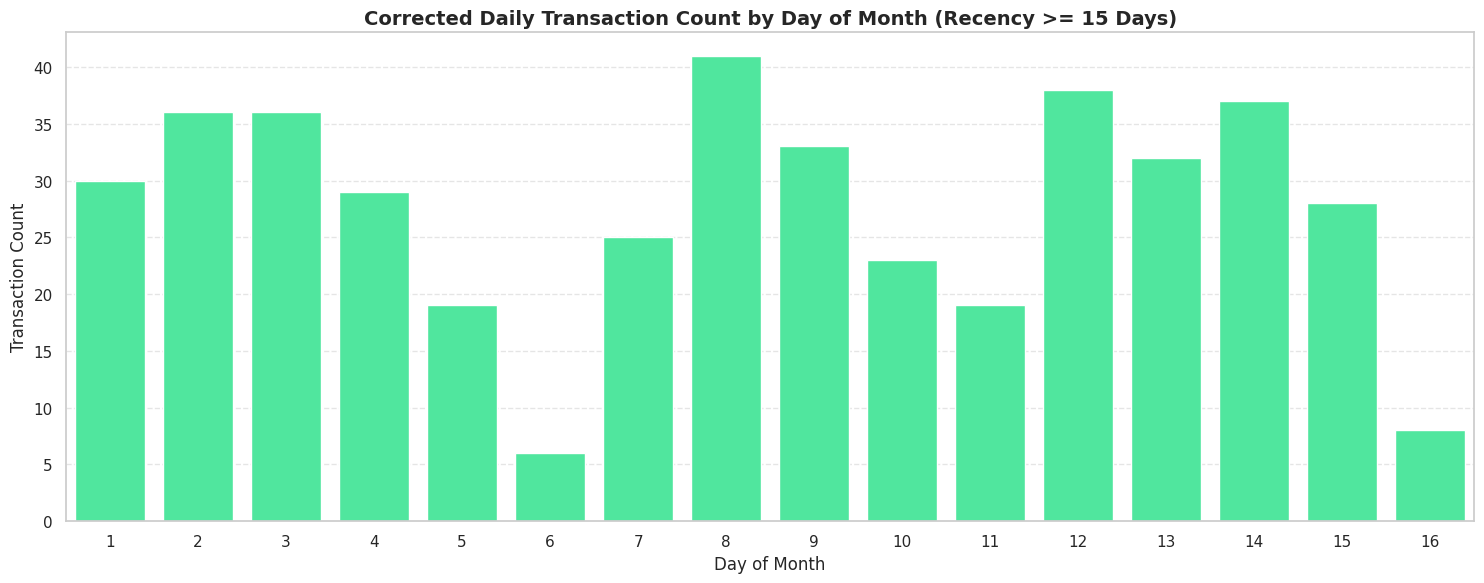

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Lọc danh sách các cặp (consumer_id, analysis_month) có recency >= 15
df_recency_cohort = df_engagement[df_engagement['transaction_recency_days'] >= 15][['consumer_id', 'analysis_month']].copy()
df_recency_cohort['analysis_month'] = pd.to_datetime(df_recency_cohort['analysis_month'])

# 2. Đảm bảo dữ liệu giao dịch có cột tháng tương ứng để khớp thông tin
df_transactions_temp = df_transactions.copy()
df_transactions_temp['activity_datetime'] = pd.to_datetime(df_transactions_temp['activity_datetime'])
# Quy về ngày đầu tháng để map với analysis_month
df_transactions_temp['analysis_month'] = df_transactions_temp['activity_datetime'].dt.to_period('M').dt.to_timestamp()

# 3. Thực hiện merge để chỉ giữ lại giao dịch trong đúng tháng có recency >= 15
df_recency_transactions_strict = df_transactions_temp.merge(
    df_recency_cohort,
    on=['consumer_id', 'analysis_month'],
    how='inner'
)

# 4. Trích xuất ngày trong tháng (1 - 31)
df_recency_transactions_strict['day_of_month'] = df_recency_transactions_strict['activity_datetime'].dt.day

# 5. Thống kê lại số lượng giao dịch theo ngày
daily_stats_strict = df_recency_transactions_strict.groupby('day_of_month').agg(
    transaction_count=('transaction_id', 'count')
).reset_index()

# Hiển thị bảng số liệu đã chuẩn hóa
display(daily_stats_strict)

# 6. Vẽ lại biểu đồ chính xác
plt.figure(figsize=(15, 6))
sns.barplot(
    x='day_of_month',
    y='transaction_count',
    data=daily_stats_strict,
    color='#37ff9f'
)
plt.title('Corrected Daily Transaction Count by Day of Month (Recency >= 15 Days)', fontsize=14, weight='bold')
plt.xlabel('Day of Month')
plt.ylabel('Transaction Count')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### **Phân tích bổ sung theo yêu cầu:**
1. So sánh chi tiêu qua Mobile App & E-commerce giữa nhóm tương tác rất cao và nhóm tương tác thấp.
2. Đánh giá hình thức thanh toán thể hiện sự gắn bó lâu dài nhất của người dùng.

/tmp/ipykernel_2502/3988586800.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


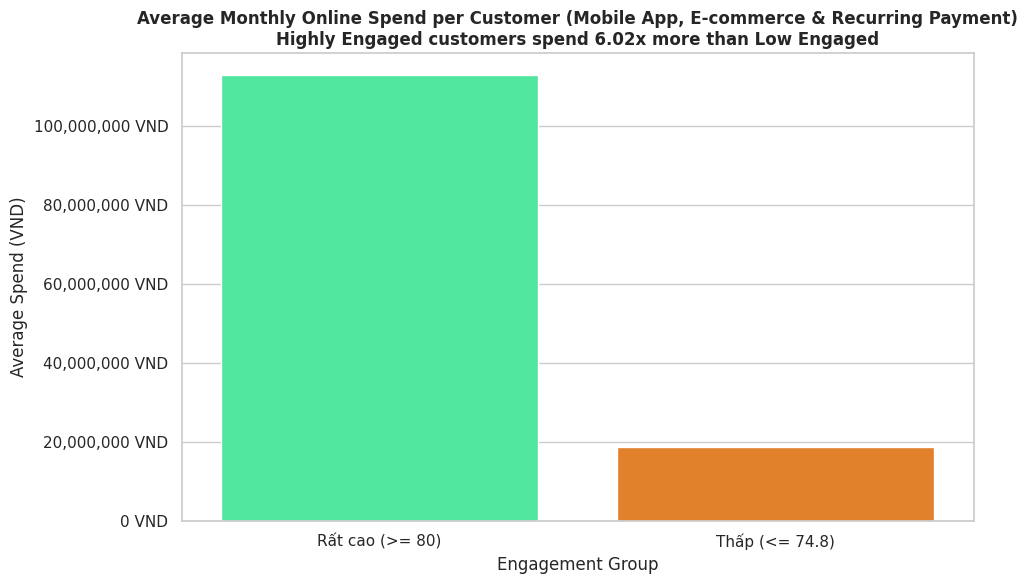

Nhóm tương tác Rất cao chi tiêu trực tuyến trung bình: 112,739,738 VND/tháng
Nhóm tương tác Thấp chi tiêu trực tuyến trung bình: 18,731,576 VND/tháng
==> Chi tiêu trực tuyến của nhóm có tương tác Rất cao gấp 6.02 lần nhóm tương tác Thấp.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- CÂU 1: SO SÁNH CHI TIÊU QUA MOBILE APP & E-COMMERCE ---

# Đảm bảo cột analysis_month trong df_engagement là dạng chuỗi yyyy-mm-dd để đồng bộ
df_eng_sub = df_engagement[['consumer_id', 'analysis_month', 'engagement_score']].copy()
df_eng_sub['analysis_month'] = pd.to_datetime(df_eng_sub['analysis_month']).dt.strftime('%Y-%m-01')

df_eng_sub['engagement_group'] = np.where(
    df_eng_sub['engagement_score'] >= 80, 'Rất cao (>= 80)',
    np.where(df_eng_sub['engagement_score'] <= 74.8, 'Thấp (<= 74.8)', 'Trung bình/Cao')
)

# Chuẩn bị dữ liệu giao dịch thuộc kênh Mobile App và E-commerce
df_trans_sub = df_transactions[
    df_transactions['transaction_channel'].isin(['Mobile App', 'E-commerce', 'Recurring Payment'])
].copy()

# Quy đổi thời gian giao dịch thành ngày đầu tháng dưới dạng chuỗi yyyy-mm-dd để khớp hoàn hảo
df_trans_sub['analysis_month'] = pd.to_datetime(df_trans_sub['activity_datetime']).dt.to_period('M').dt.to_timestamp().dt.strftime('%Y-%m-01')

# Ghép nhóm tương tác của khách hàng vào từng giao dịch
df_trans_grouped = df_trans_sub.merge(
    df_eng_sub,
    on=['consumer_id', 'analysis_month'],
    how='inner'
)

# Tính tổng chi tiêu trực tuyến hàng tháng của mỗi khách hàng
spend_by_customer_month = df_trans_grouped.groupby(['engagement_group', 'consumer_id', 'analysis_month'])['spend_amount_vnd'].sum().reset_index()

# Tính trung bình chi tiêu hàng tháng trên mỗi khách hàng theo từng nhóm tương tác
avg_spend_by_group = spend_by_customer_month.groupby('engagement_group')['spend_amount_vnd'].mean().reset_index()

# Lấy giá trị cụ thể để tính tỷ lệ chênh lệch chi tiêu trực tuyến
spend_high = avg_spend_by_group[avg_spend_by_group['engagement_group'] == 'Rất cao (>= 80)']['spend_amount_vnd'].values[0]
spend_low = avg_spend_by_group[avg_spend_by_group['engagement_group'] == 'Thấp (<= 74.8)']['spend_amount_vnd'].values[0]
ratio = spend_high / spend_low

# Vẽ biểu đồ so sánh chi tiêu trực tuyến
plt.figure(figsize=(10, 6))
sns.barplot(
    x='engagement_group',
    y='spend_amount_vnd',
    data=avg_spend_by_group[avg_spend_by_group['engagement_group'].isin(['Rất cao (>= 80)', 'Thấp (<= 74.8)'])],
    palette=['#37ff9f', '#ff7f0e']
)
plt.title(f'Average Monthly Online Spend per Customer (Mobile App, E-commerce & Recurring Payment)\nHighly Engaged customers spend {ratio:.2f}x more than Low Engaged', fontsize=12, weight='bold')
plt.xlabel('Engagement Group')
plt.ylabel('Average Spend (VND)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f} VND'))
plt.tight_layout()
plt.show()

print(f"Nhóm tương tác Rất cao chi tiêu trực tuyến trung bình: {spend_high:,.0f} VND/tháng")
print(f"Nhóm tương tác Thấp chi tiêu trực tuyến trung bình: {spend_low:,.0f} VND/tháng")
print(f"==> Chi tiêu trực tuyến của nhóm có tương tác Rất cao gấp {ratio:.2f} lần nhóm tương tác Thấp.\n")

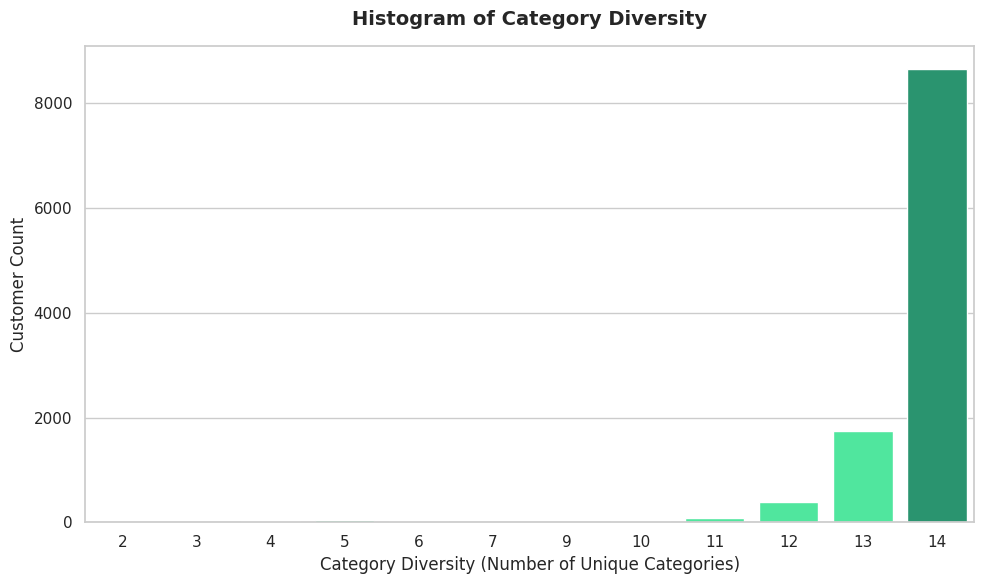

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the style
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'

# Set figure size
plt.figure(figsize=(10, 6))

# Count occurrences of each category_diversity value
diversity_counts = df_engagement['category_diversity'].value_counts().sort_index()
x_values = diversity_counts.index
y_values = diversity_counts.values

# Find the index of the maximum bar
max_idx = np.argmax(y_values)

# Define colors: '#18a674' for the highest bar, '#37ff9f' for the rest
colors = ['#18a674' if i == max_idx else '#37ff9f' for i in range(len(x_values))]

# Plotting using barplot to easily apply customized color per bar
sns.barplot(x=x_values, y=y_values, palette=colors, hue=x_values, legend=False)

# Add titles and labels
plt.title('Histogram of Category Diversity', fontsize=14, weight='bold', pad=15)
plt.xlabel('Category Diversity (Number of Unique Categories)', fontsize=12)
plt.ylabel('Customer Count', fontsize=12)

# Adjust layout and display
plt.tight_layout()
plt.show()